# qGAN circuit atlas

Draw the generator, discriminator, real-data input, and random input, followed by
**random → generator**, **generator → discriminator**, **real → discriminator**, and
**random → generator → discriminator** for `qml_torch`, `runtime-packed-sep`,
and `runtime-packed-join` across the supported `base`, `ang`, and `amp` presets.

The diagrams use the current project circuit functions, without transpilation,
training, backend access, or saved datasets. The example uses four qubits and
the repository's configured generator and discriminator types.
`encoding.randomness = 1` and `encoding.random_circuit = 1` make the random
input visible even though the supplied single-run YAML defaults to zero
randomness. For `ang`, the random and real inputs share the same RY structure;
each receives independent values during a run.

Runtime sections show the detailed four-qubit generator/fake and real
training circuits. Joined packing also shows one detailed eight-qubit
real/fake discriminator circuit. Larger training jobs are drawn as labelled
boxes, one per four-qubit sample, while retaining the gates inside each box.
`amp` does not support joined discriminator packing.

## Setup

Run with the project's notebook environment (`pip install -e "qgan[results]"`).
The path cell works from the repository root or `qgan/notebooks`. All circuit
construction and plotting lives in `qgan_v2.visualization.circuit_atlas`.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
qgan_dir = next(
    (
        candidate
        for root in (cwd, *cwd.parents)
        for candidate in (root, root / "qgan")
        if (candidate / "src" / "qgan_v2").is_dir()
    ),
    None,
)
if qgan_dir is None:
    raise RuntimeError("Could not find the qgan project directory.")

src_path = qgan_dir / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from qgan_v2.visualization import CircuitAtlas

## Display and PNG export

Set `CREATE_PNG = True` below to save the same circuit images shown in the notebook.
Files use names such as `qml_torch_base_random_gen.png` in `FIGURE_DIR`.
The directory is created only when export is enabled.


In [2]:
# Set True to save every displayed circuit as a 300-dpi PNG.
CREATE_PNG = False
FIGURE_DIR = qgan_dir / "figures" / "circuit_atlas"

atlas = CircuitAtlas(
    qgan_dir,
    figure_dir=FIGURE_DIR,
    n_qubits=4,
    randomness=1.0,
    random_circuit=1,
    packed_batch_size=4,
)
print("PNG directory:", atlas.figure_dir)

PNG directory: /home/benat/Qiskit-IBM/qgan/figures/circuit_atlas


## qml_torch

### base

The real circuit prepares the specific quantum distribution.

**qml_torch / base** · encoding: `direct_circuit` · real circuits: 1 · randomness: 1.0

#### Generator — 4 qubits

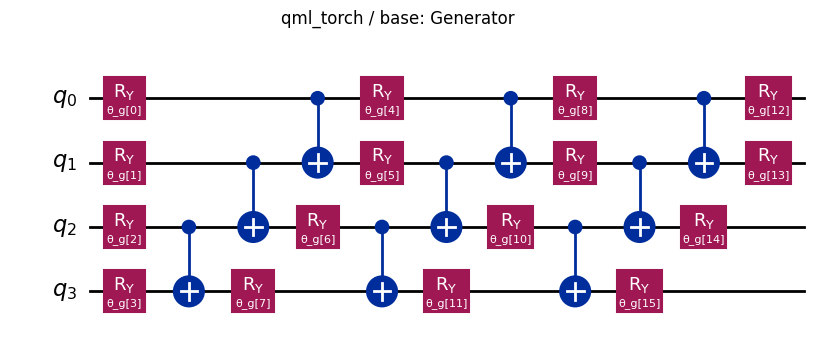

#### Discriminator — 4 qubits

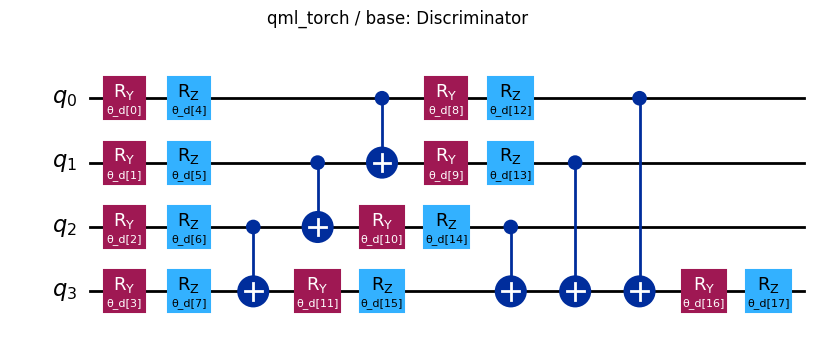

#### Real input (sample 0) — 4 qubits

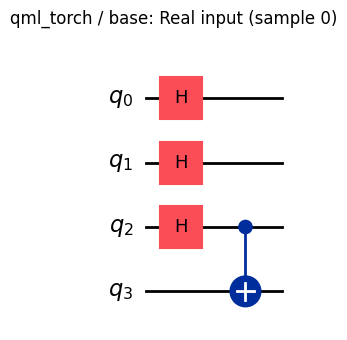

#### Random input — 4 qubits

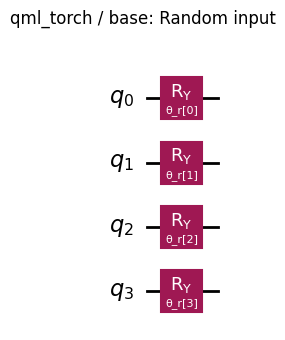

#### Random → generator — 4 qubits

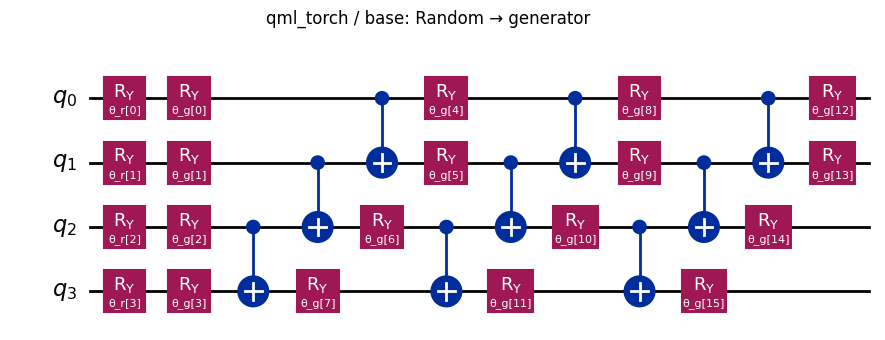

#### Generator → discriminator — 4 qubits

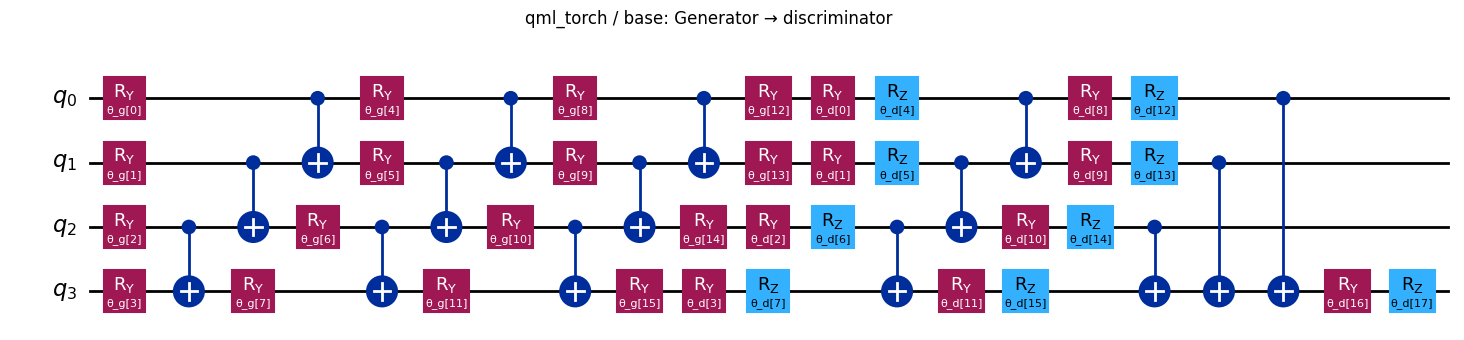

#### Real → discriminator — 4 qubits

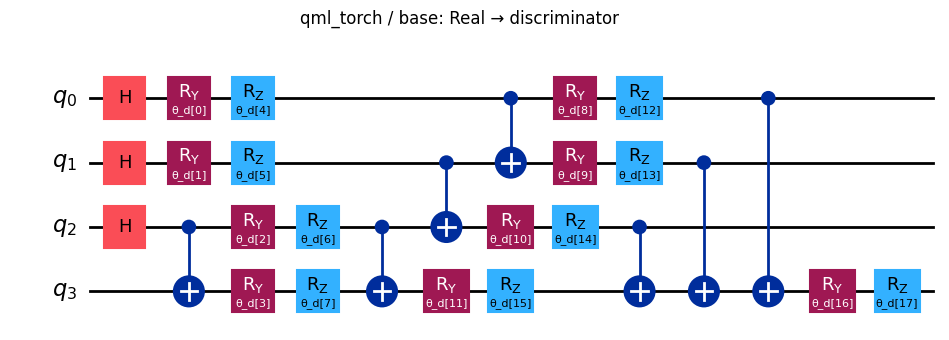

#### Random → generator → discriminator — 4 qubits

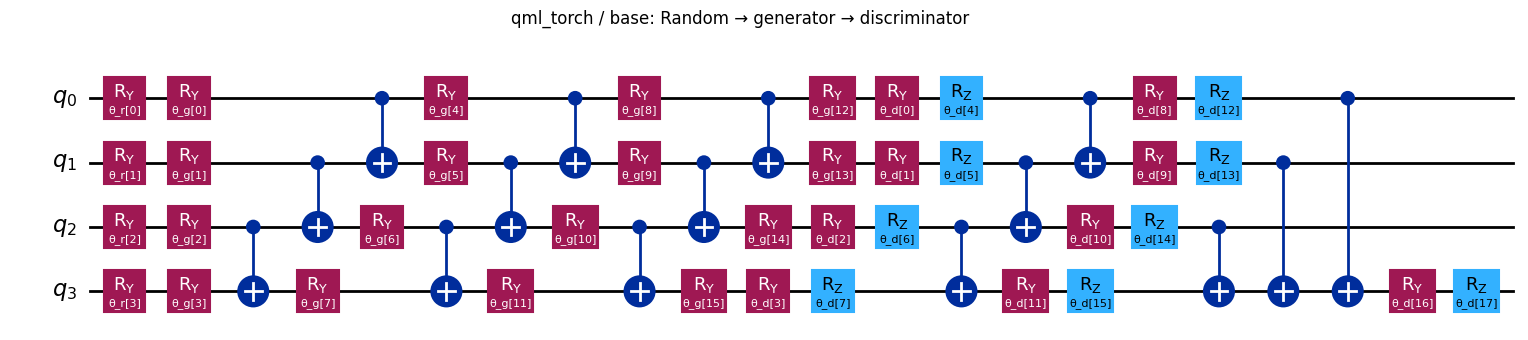

In [3]:
_ = atlas.show_case("base", "qml_torch", save_figures=CREATE_PNG)

### ang

The real circuit uses one RY angle per qubit.

**qml_torch / ang** · encoding: `angle` · real circuits: 1 · randomness: 1.0

#### Generator — 4 qubits

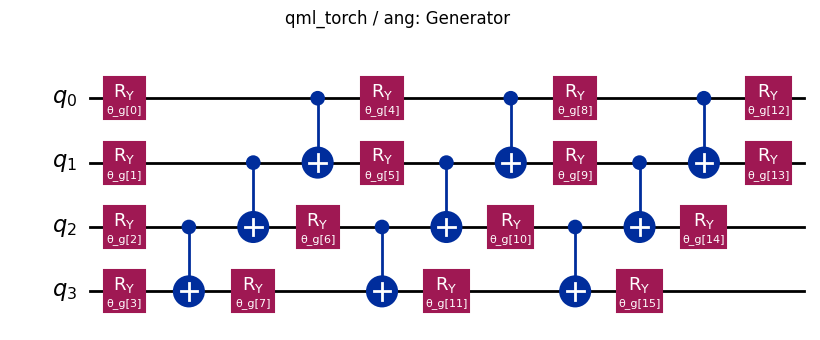

#### Discriminator — 4 qubits

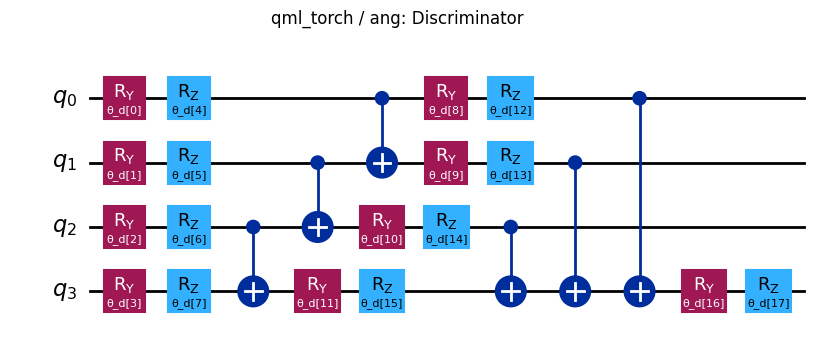

#### Real input (sample 0) — 4 qubits

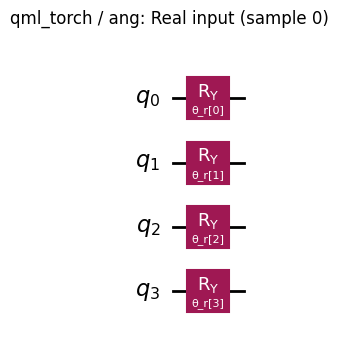

#### Random input — 4 qubits

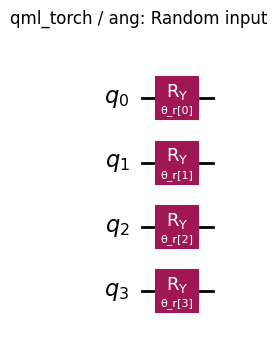

#### Random → generator — 4 qubits

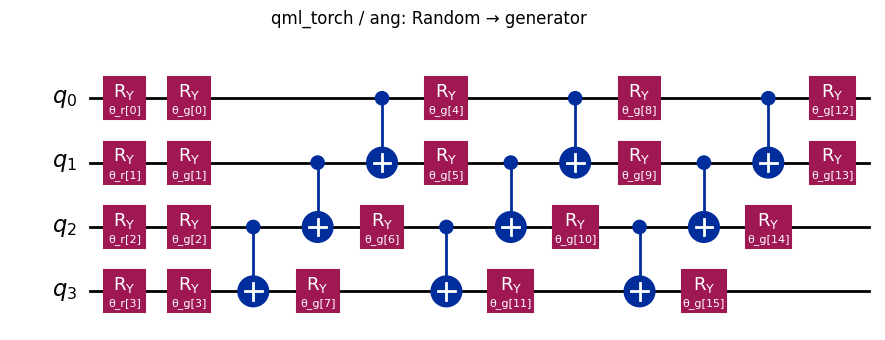

#### Generator → discriminator — 4 qubits

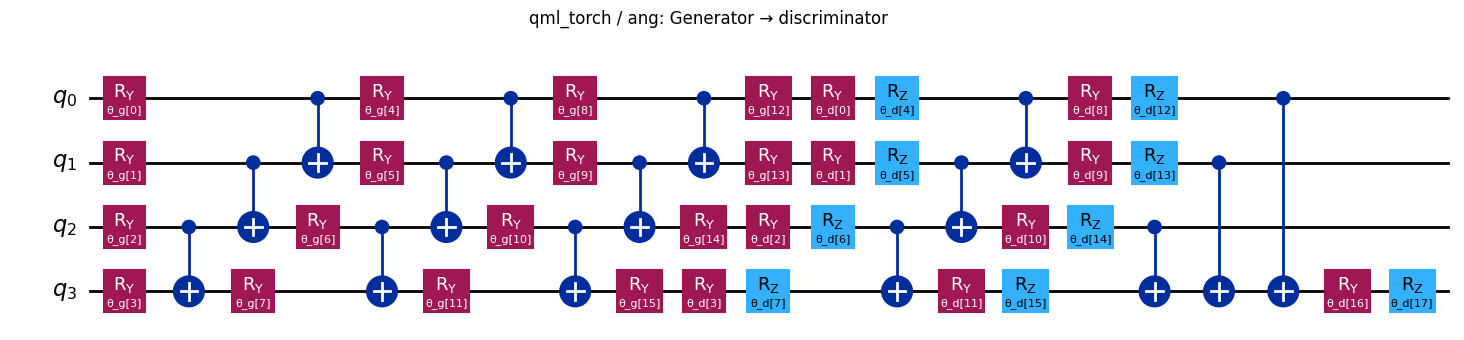

#### Real → discriminator — 4 qubits

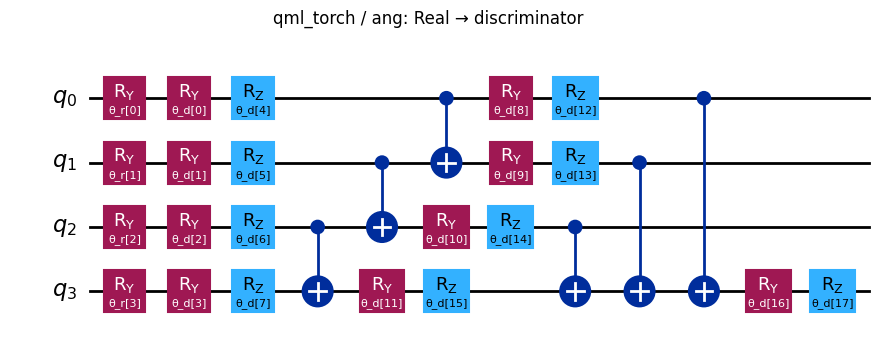

#### Random → generator → discriminator — 4 qubits

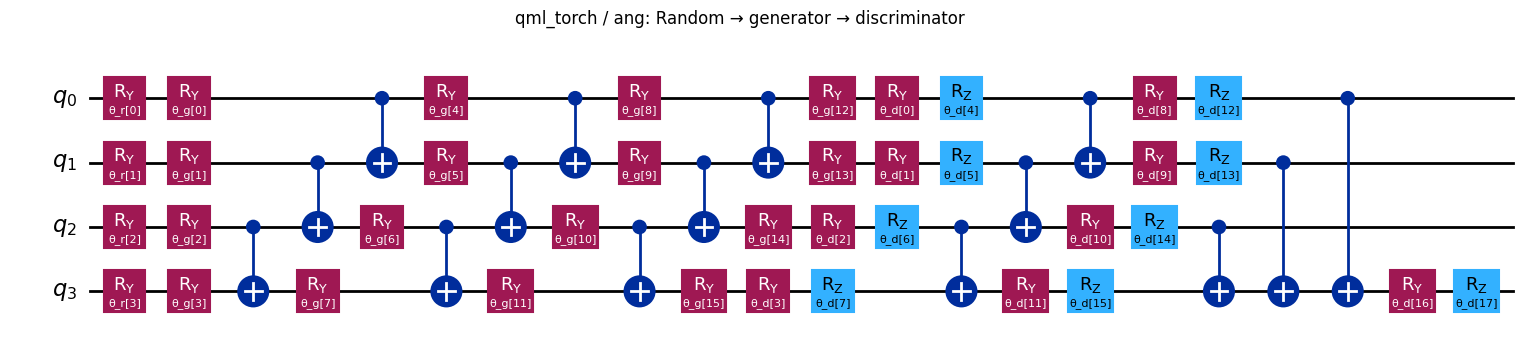

In [4]:
_ = atlas.show_case("ang", "qml_torch", save_figures=CREATE_PNG)

### amp

The real circuit prepares amplitudes from one generated gradient image.

**qml_torch / amp** · encoding: `amplitude` · real circuits: 7 · randomness: 1.0

Showing real sample 0; other samples use the same encoding path.

#### Generator — 4 qubits

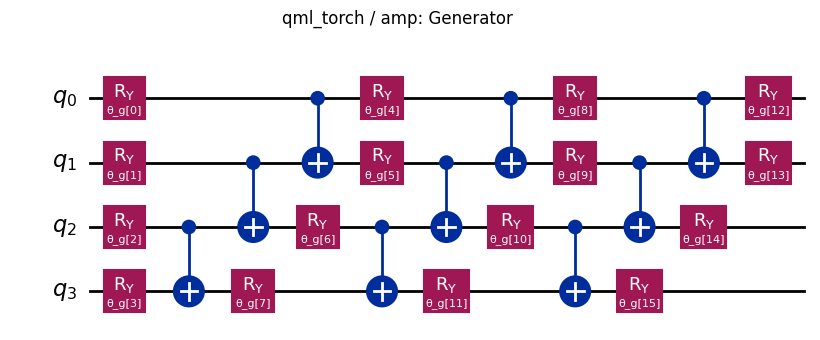

#### Discriminator — 4 qubits

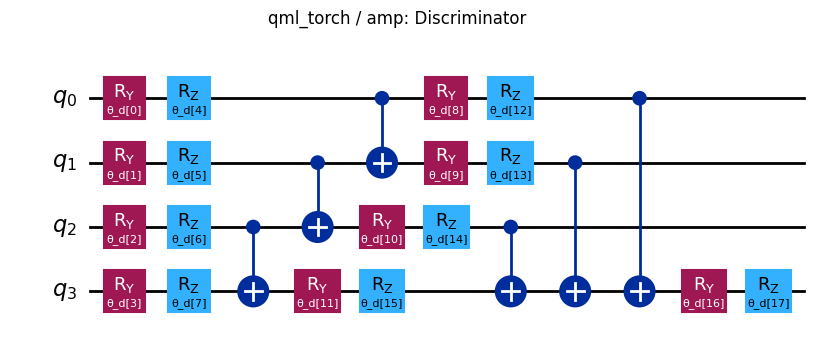

#### Real input (sample 0) — 4 qubits

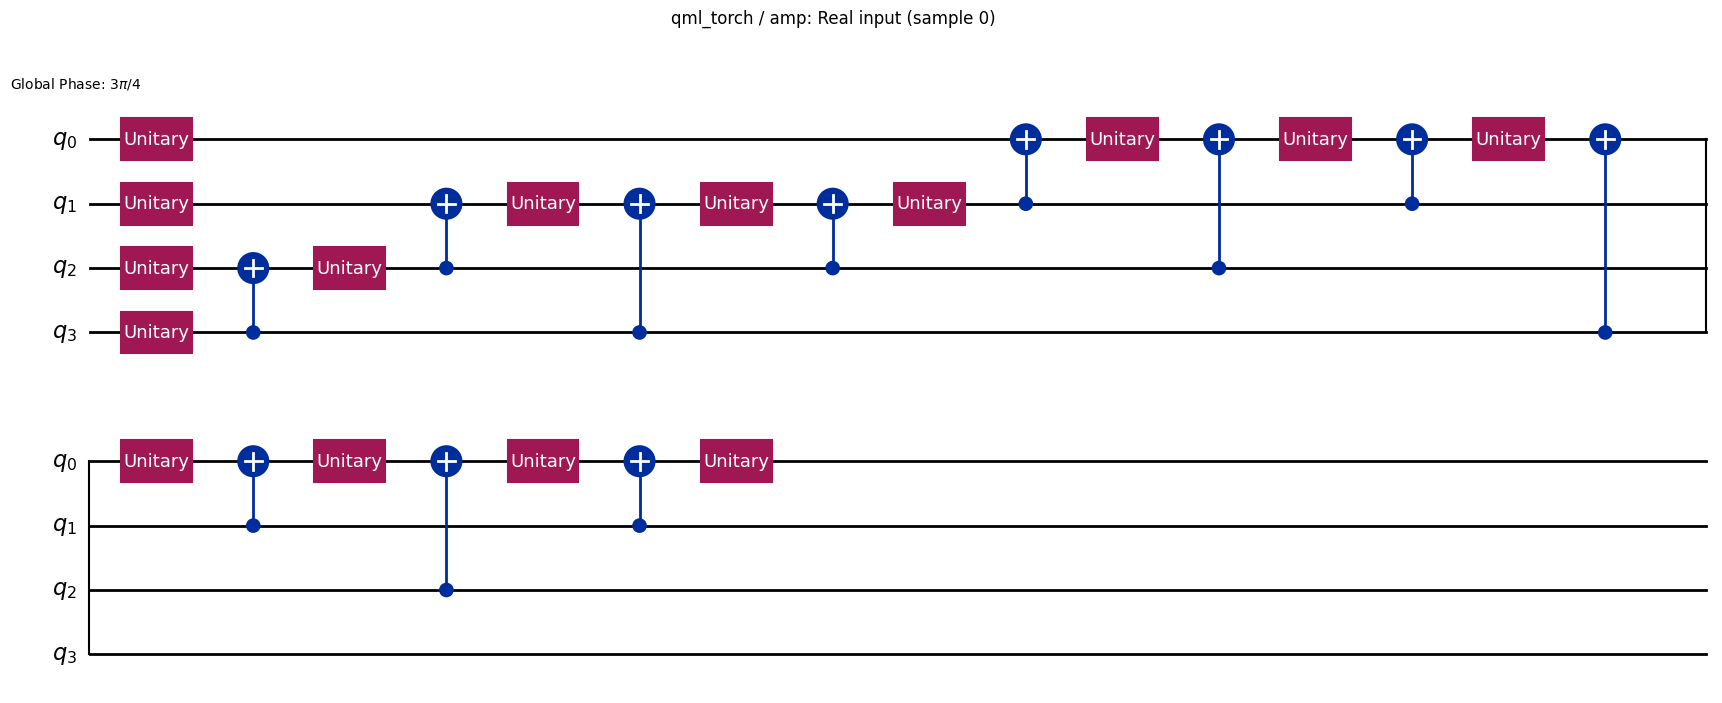

#### Random input — 4 qubits

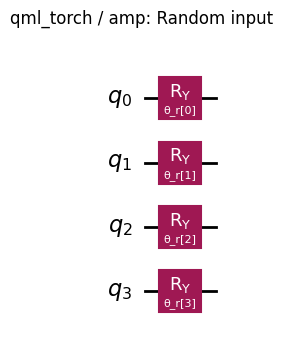

#### Random → generator — 4 qubits

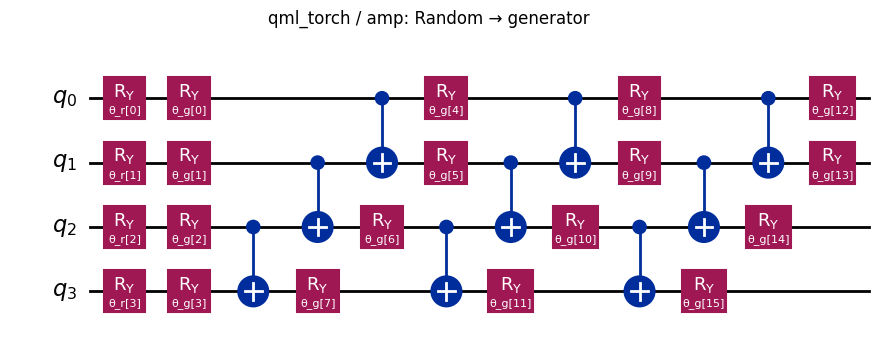

#### Generator → discriminator — 4 qubits

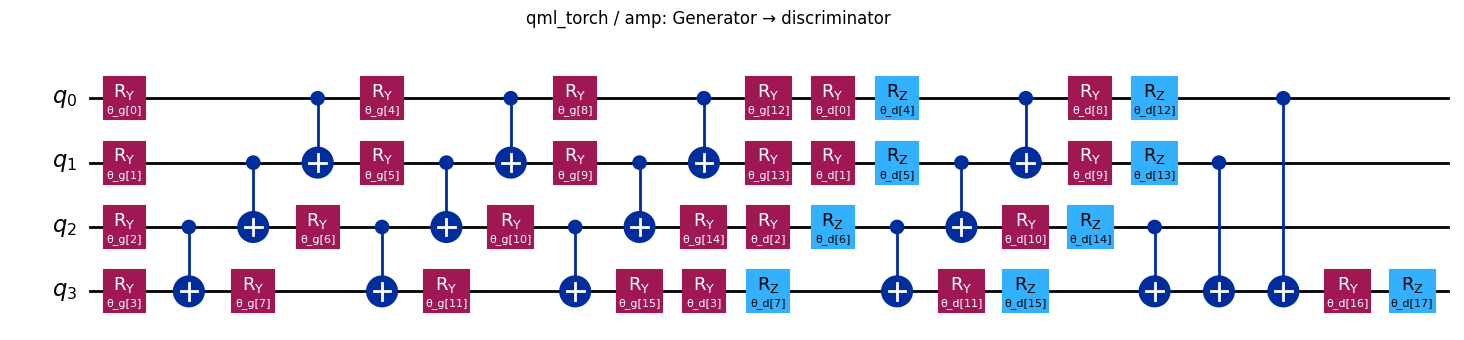

#### Real → discriminator — 4 qubits

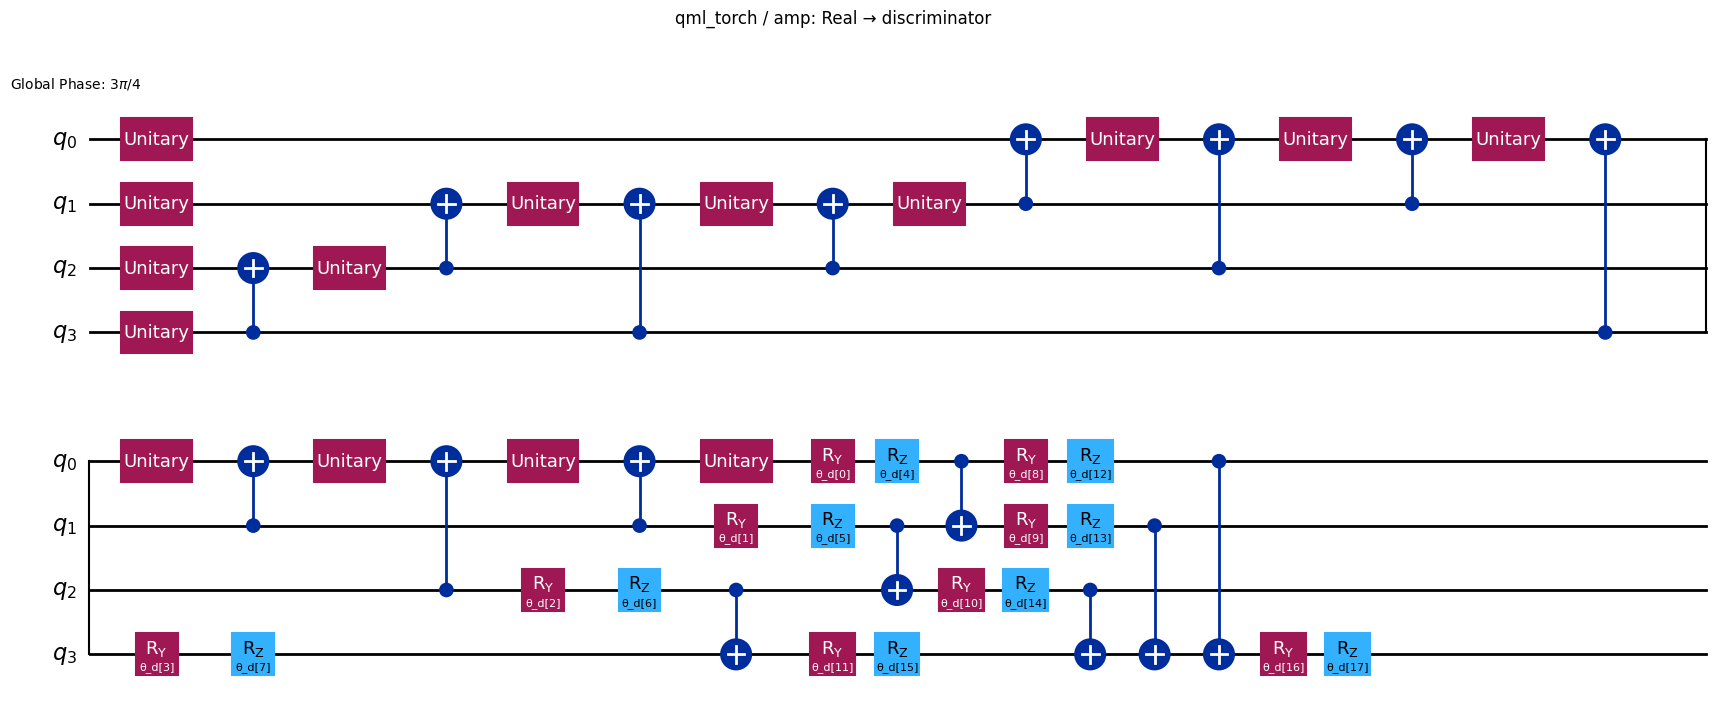

#### Random → generator → discriminator — 4 qubits

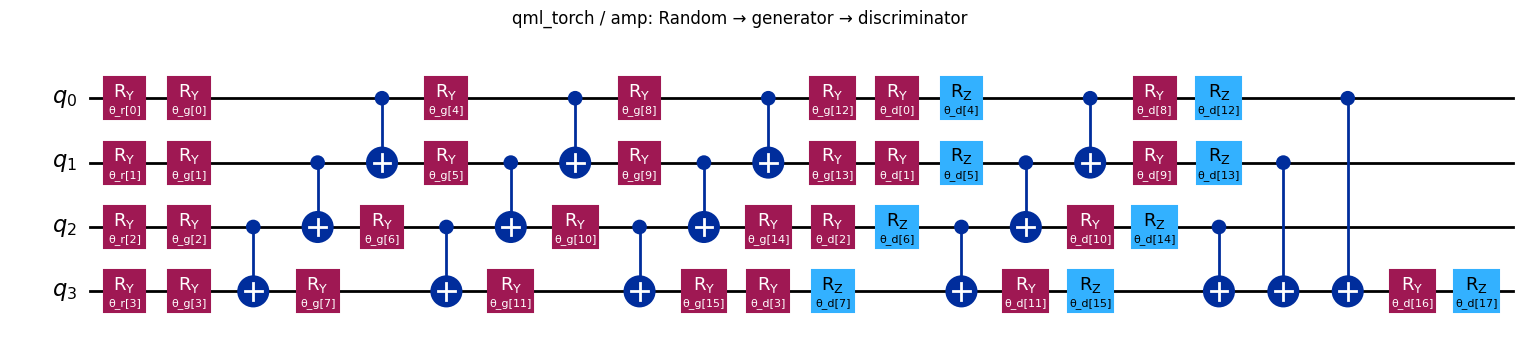

In [5]:
_ = atlas.show_case("amp", "qml_torch", save_figures=CREATE_PNG)

## runtime-packed-sep

### base

The real circuit prepares the specific quantum distribution.

**runtime-packed-sep / base** · encoding: `direct_circuit` · real circuits: 1 · randomness: 1.0

#### Generator — 4 qubits

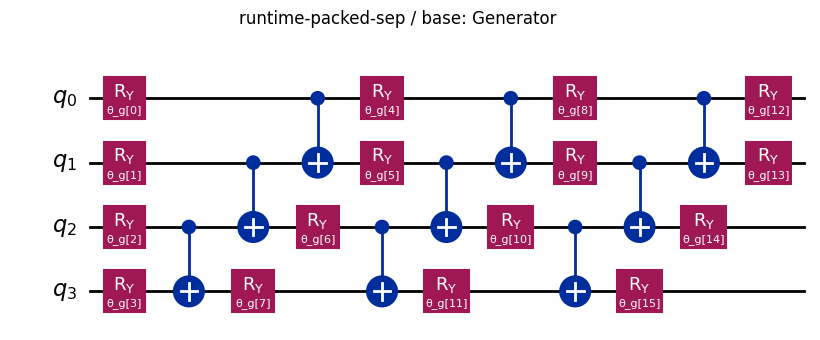

#### Discriminator — 4 qubits

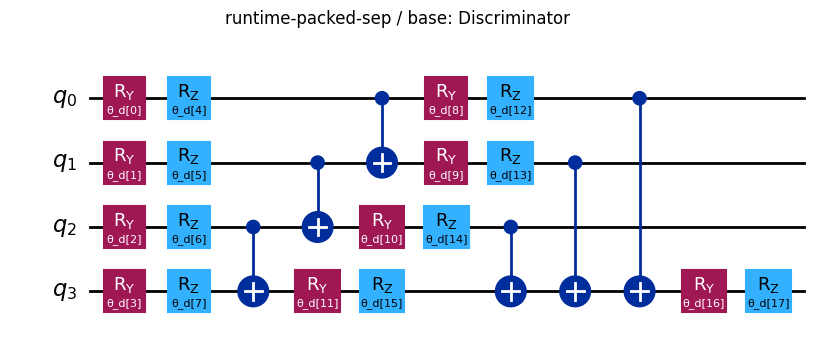

#### Real input (sample 0) — 4 qubits

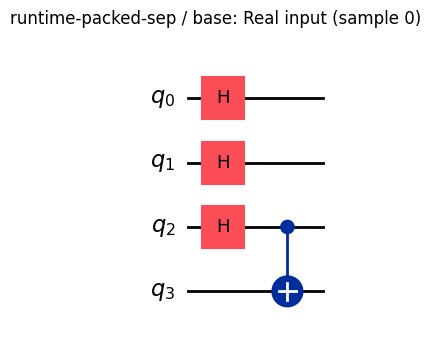

#### Random input — 4 qubits

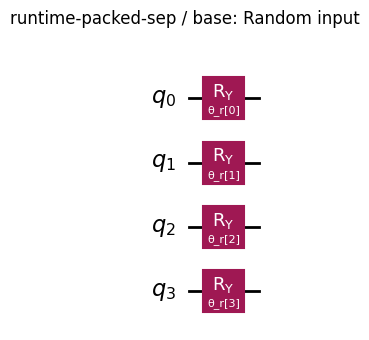

#### Random → generator — 4 qubits

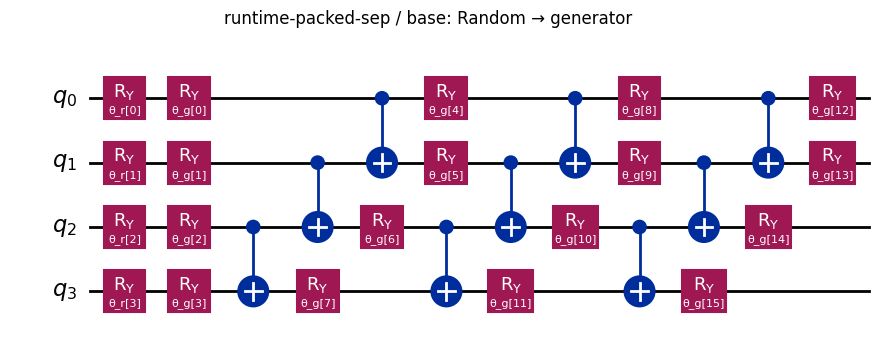

#### Generator → discriminator — 4 qubits

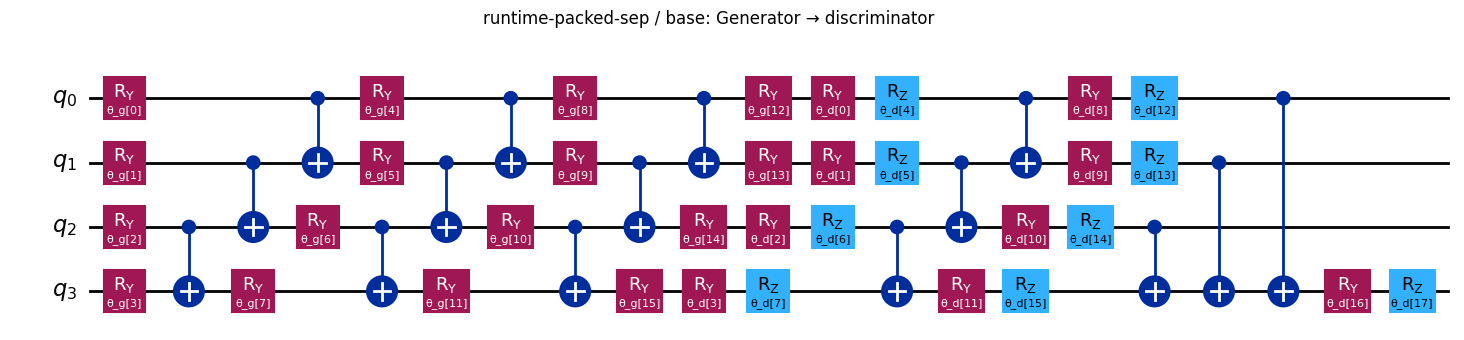

#### Generator training / fake discriminator circuit — 4 qubits

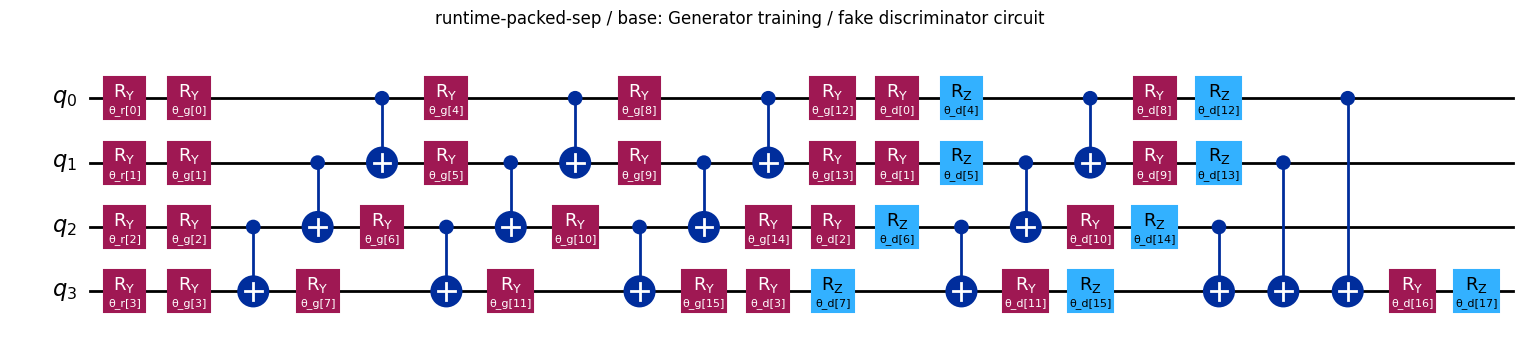

#### Real discriminator circuit — 4 qubits

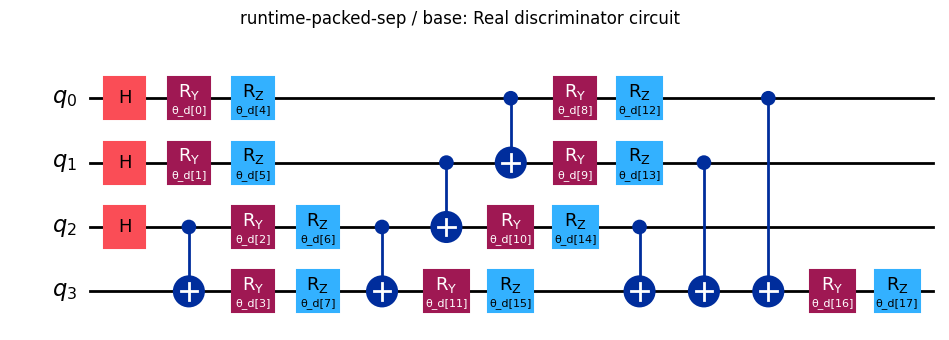

#### Generator training / fake discriminator packed job — 4 qubits

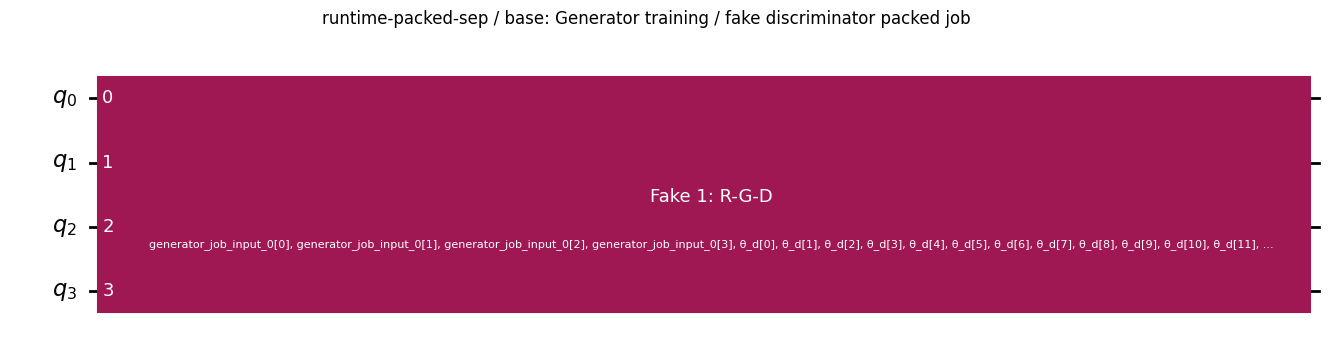

#### Real discriminator packed job — 4 qubits

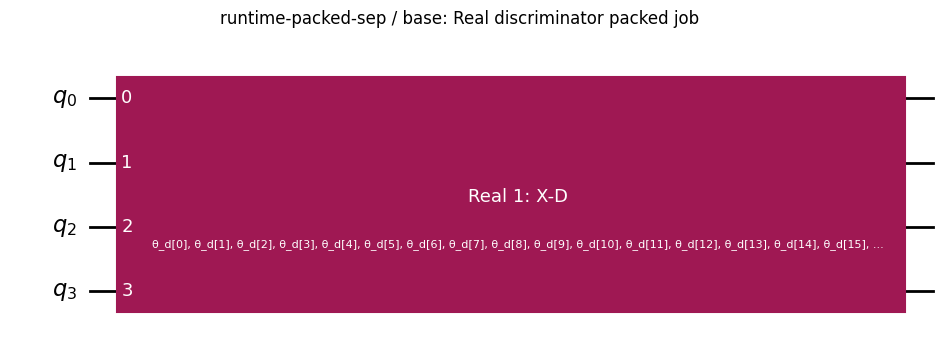

In [6]:
_ = atlas.show_case("base", "runtime-packed-sep", save_figures=CREATE_PNG)

### ang

The real circuit uses one RY angle per qubit.

**runtime-packed-sep / ang** · encoding: `angle` · real circuits: 1 · randomness: 1.0

#### Generator — 4 qubits

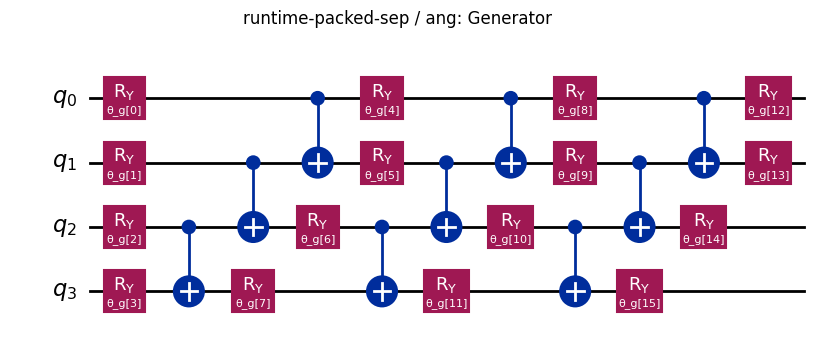

#### Discriminator — 4 qubits

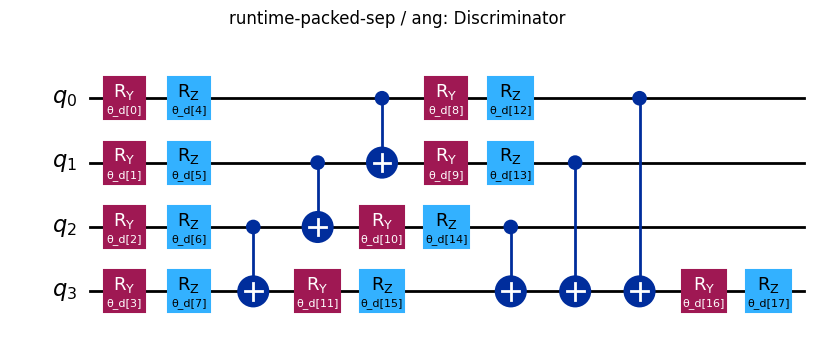

#### Real input (sample 0) — 4 qubits

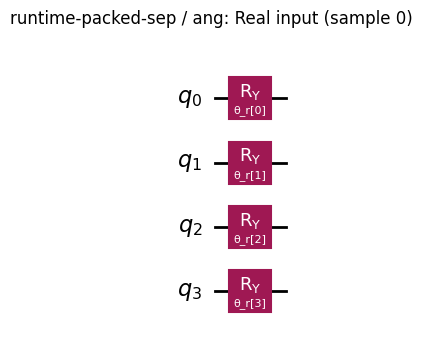

#### Random input — 4 qubits

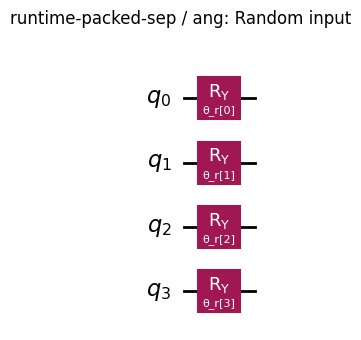

#### Random → generator — 4 qubits

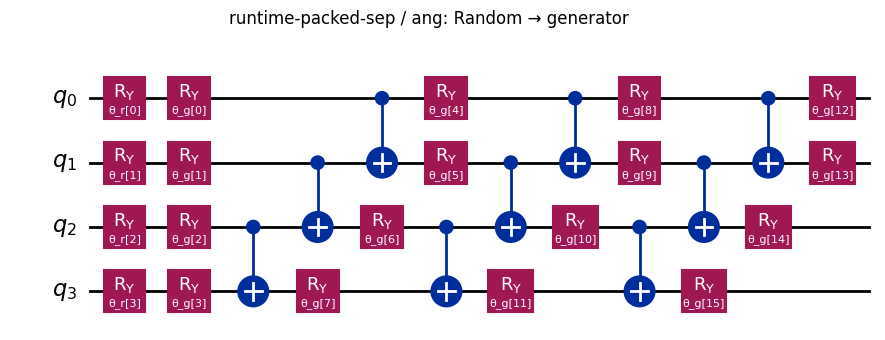

#### Generator → discriminator — 4 qubits

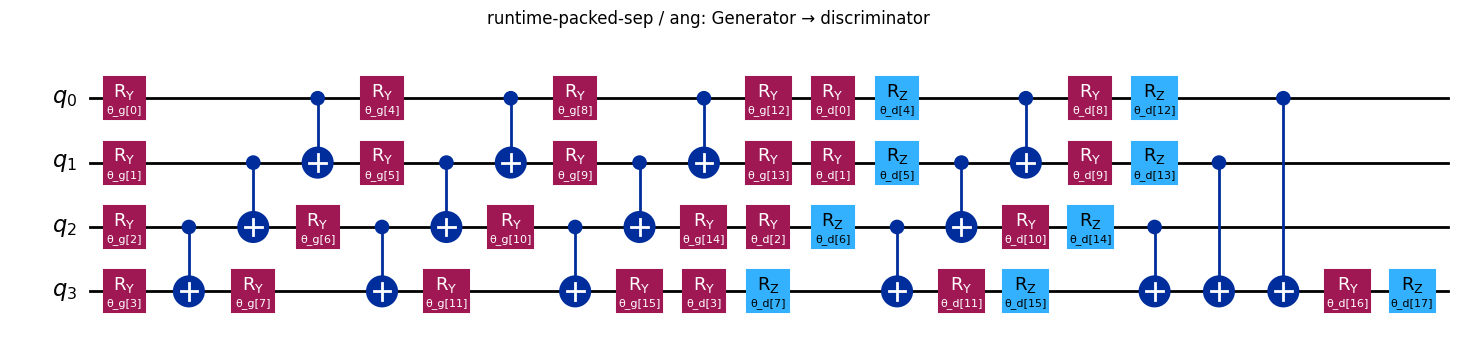

#### Generator training / fake discriminator circuit — 4 qubits

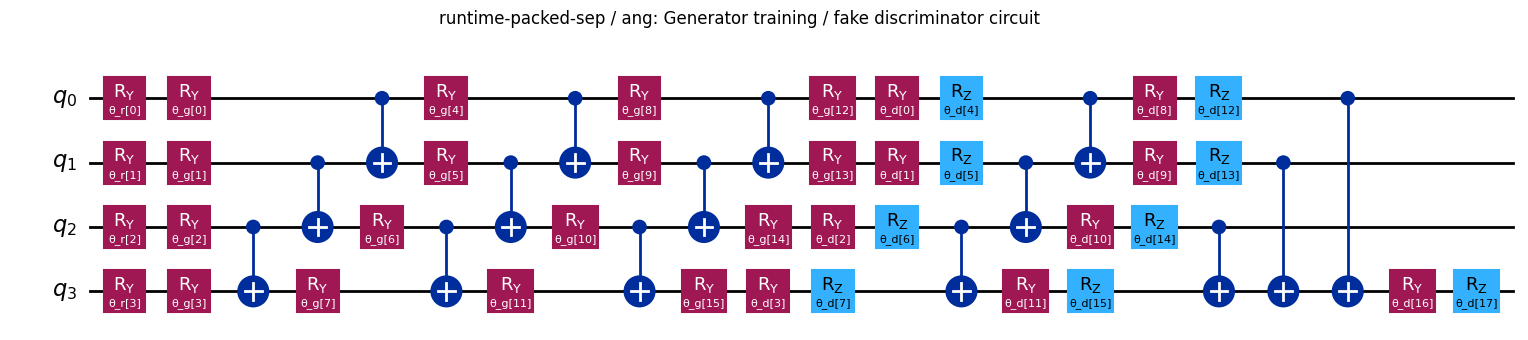

#### Real discriminator circuit — 4 qubits

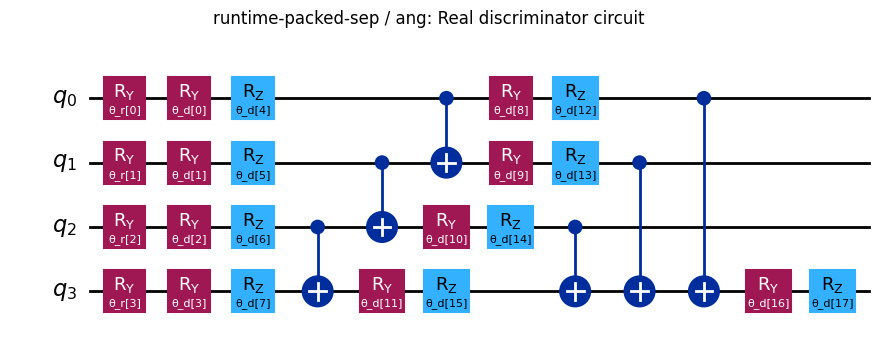

#### Generator training / fake discriminator packed job — 16 qubits

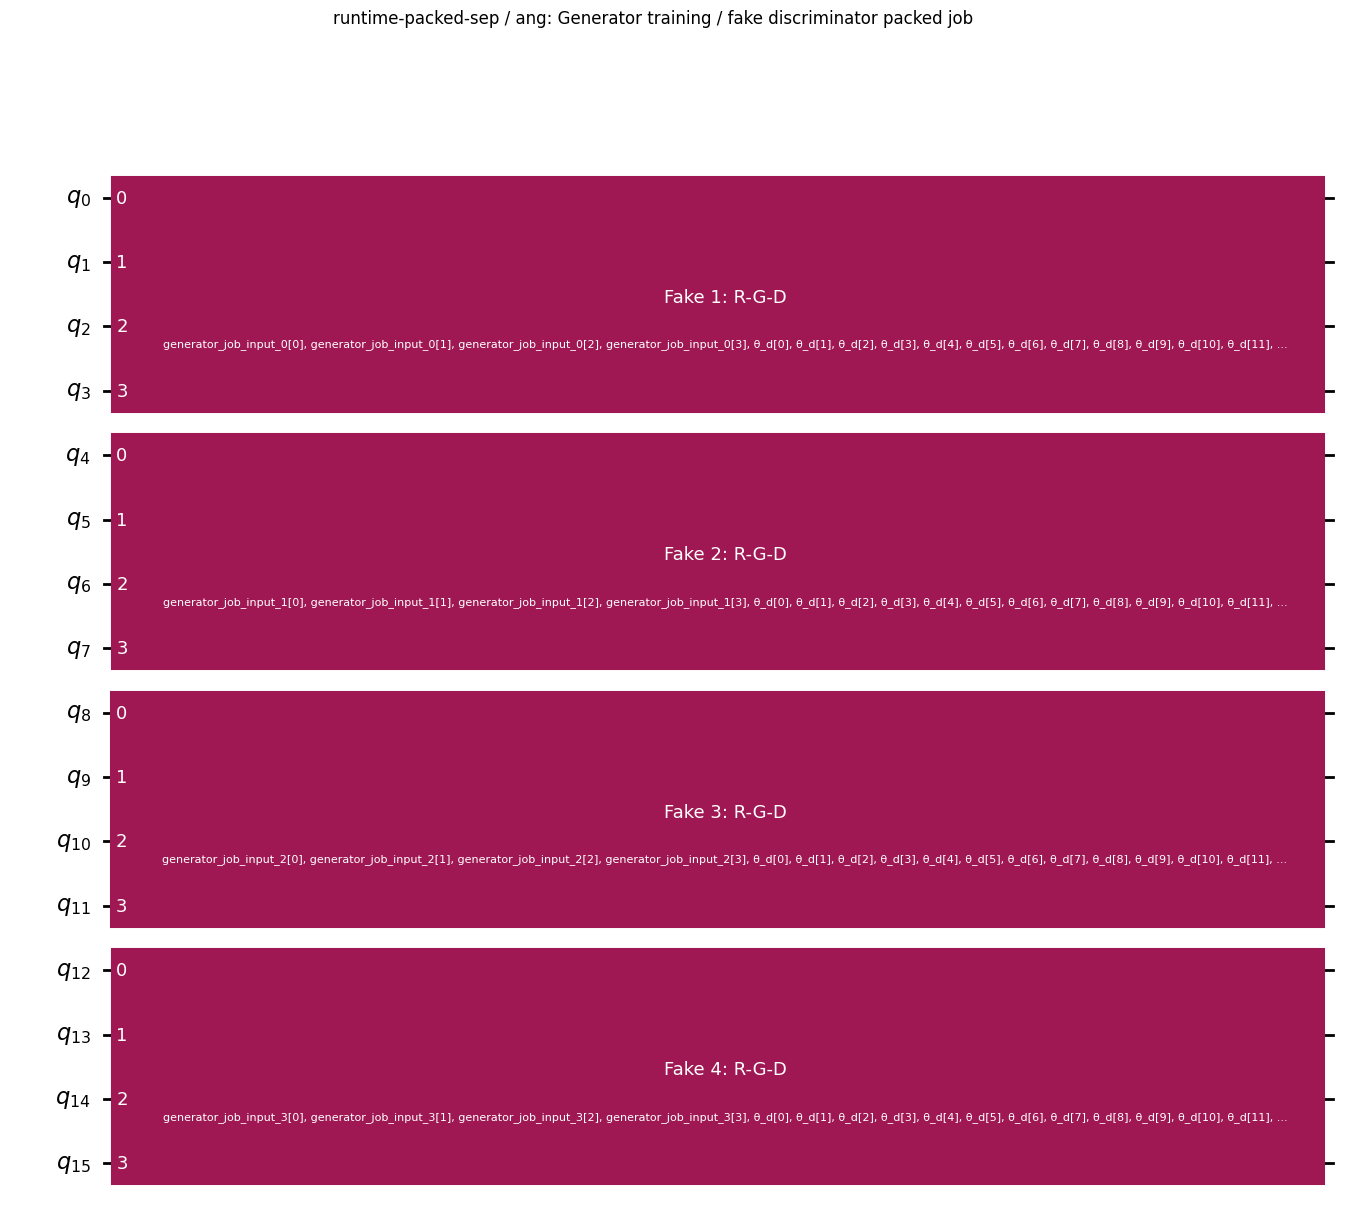

#### Real discriminator packed job — 16 qubits

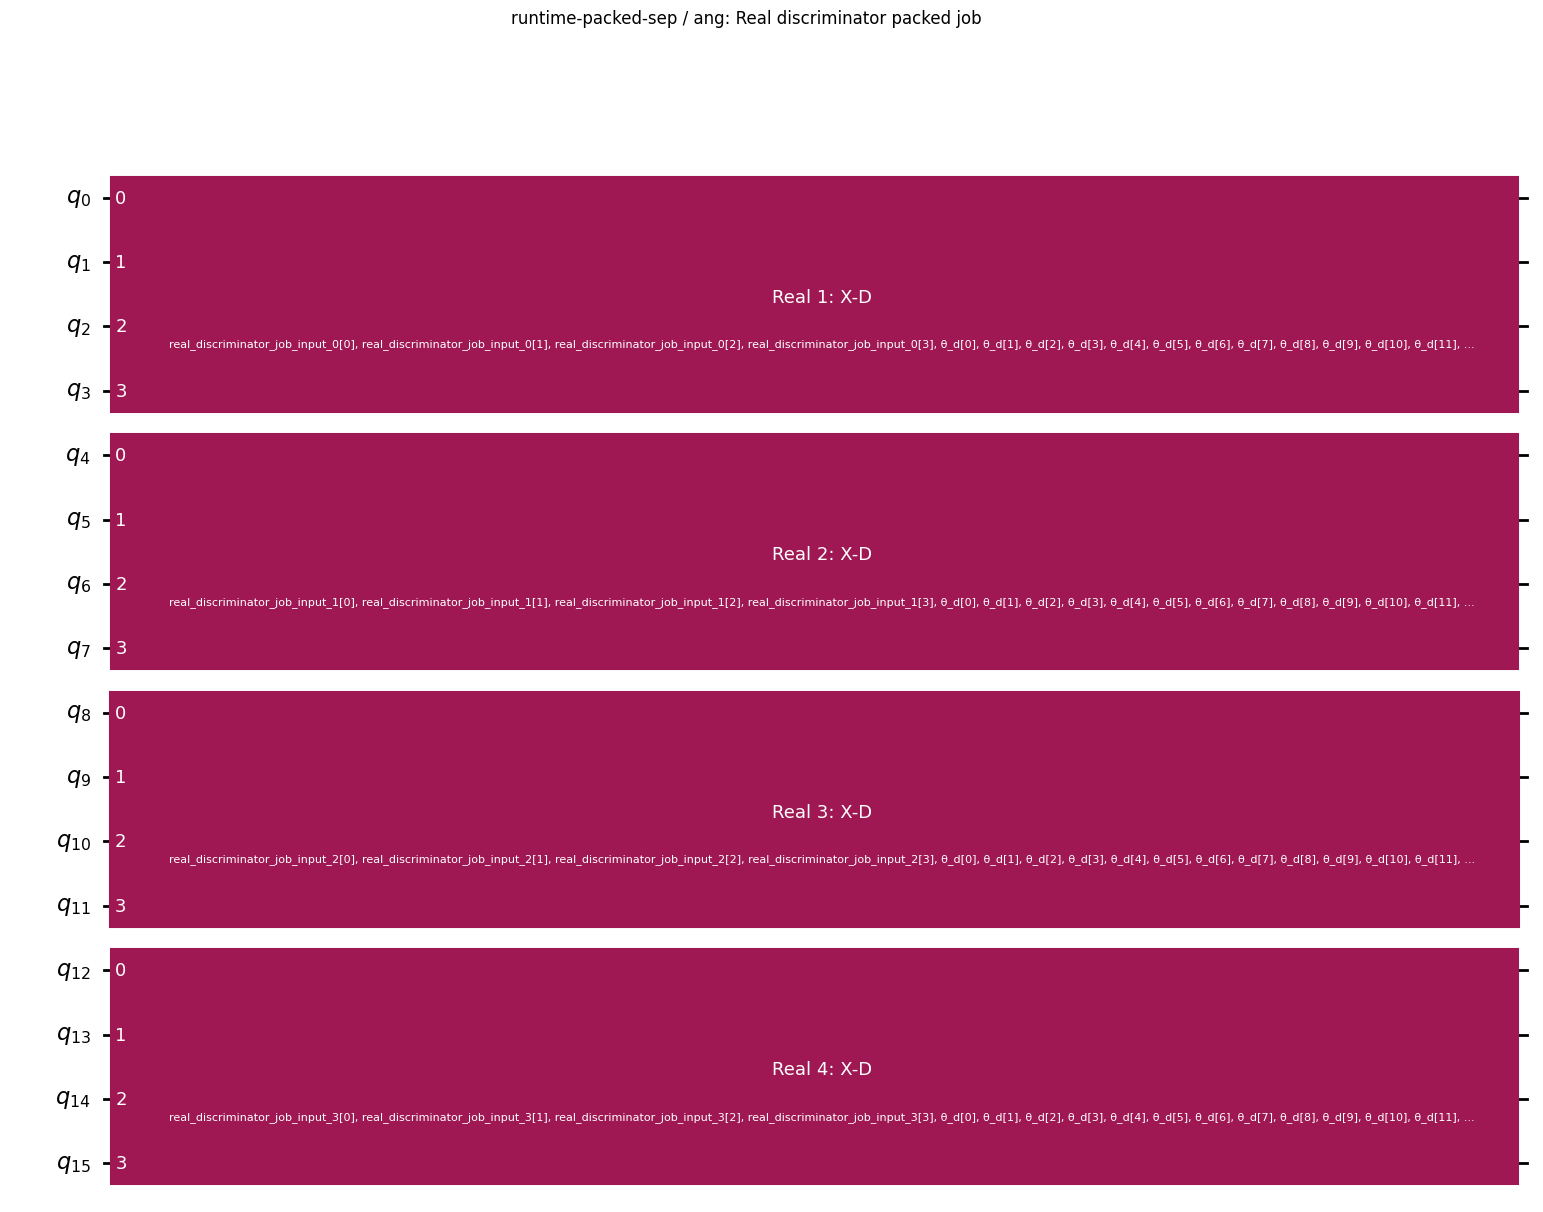

In [7]:
_ = atlas.show_case("ang", "runtime-packed-sep", save_figures=CREATE_PNG)

### amp

The real circuit prepares amplitudes from one generated gradient image.

**runtime-packed-sep / amp** · encoding: `amplitude` · real circuits: 7 · randomness: 1.0

Showing real sample 0; other samples use the same encoding path.

#### Generator — 4 qubits

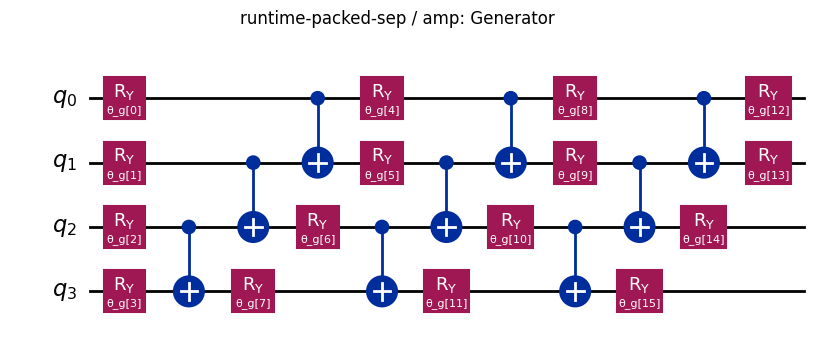

#### Discriminator — 4 qubits

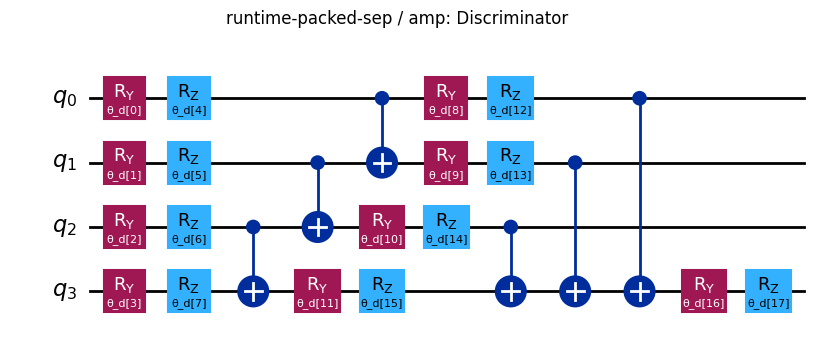

#### Real input (sample 0) — 4 qubits

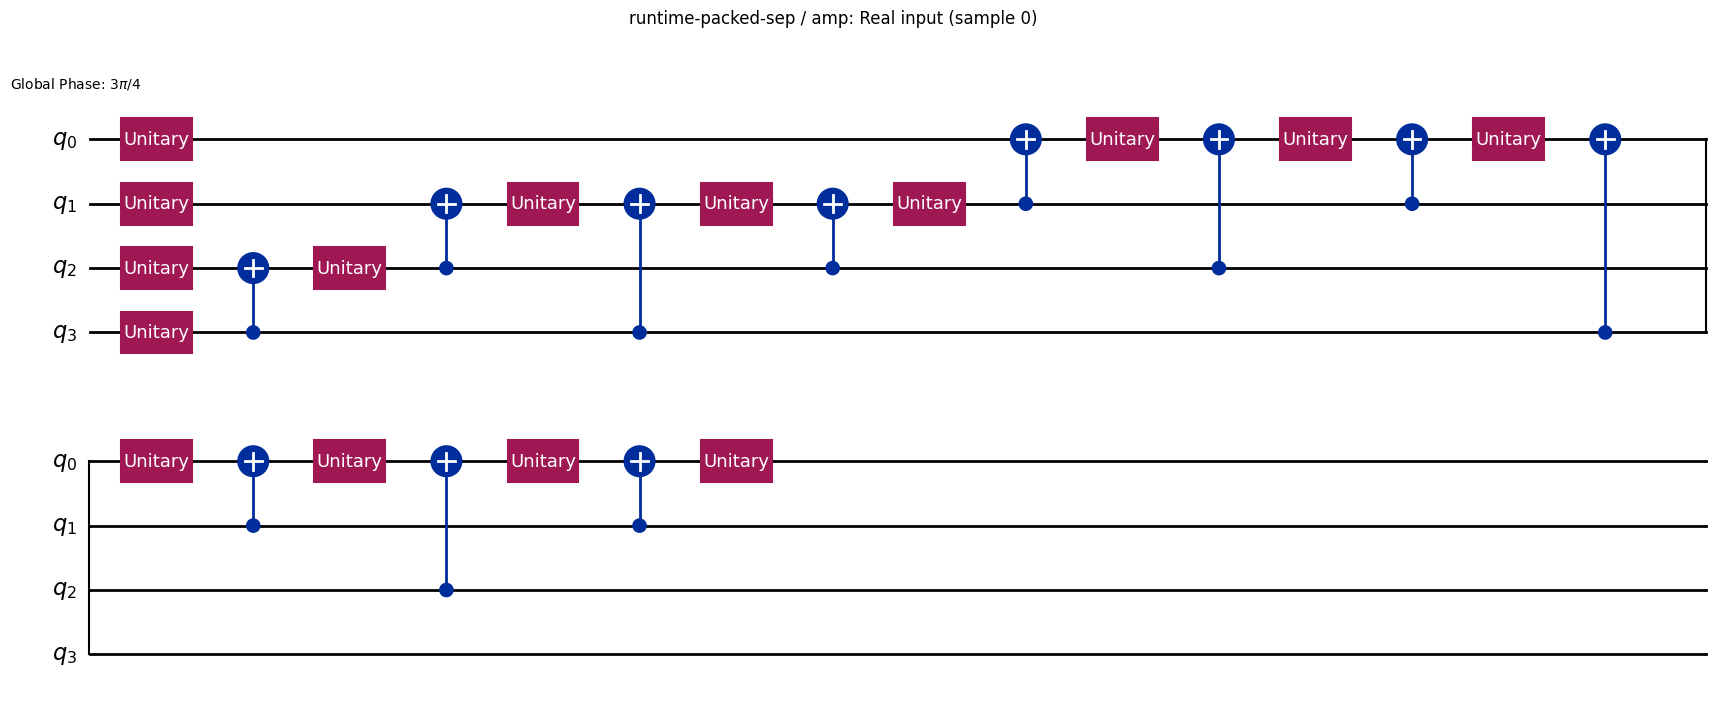

#### Random input — 4 qubits

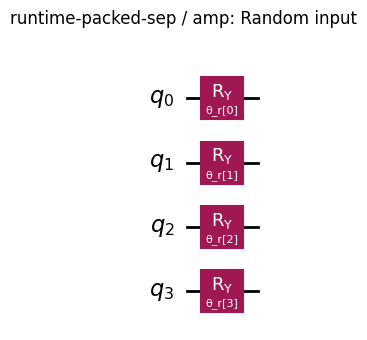

#### Random → generator — 4 qubits

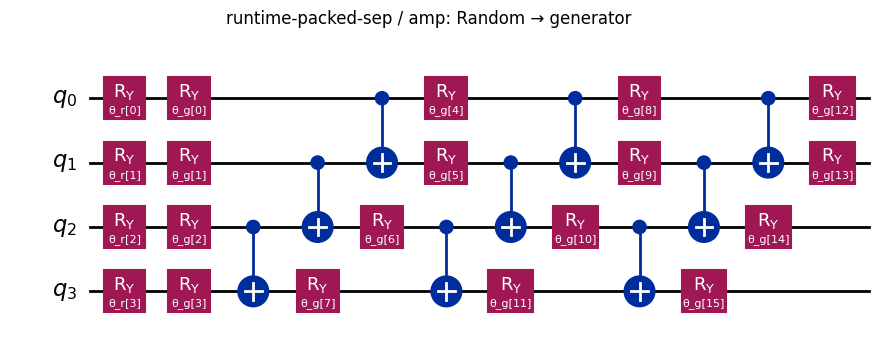

#### Generator → discriminator — 4 qubits

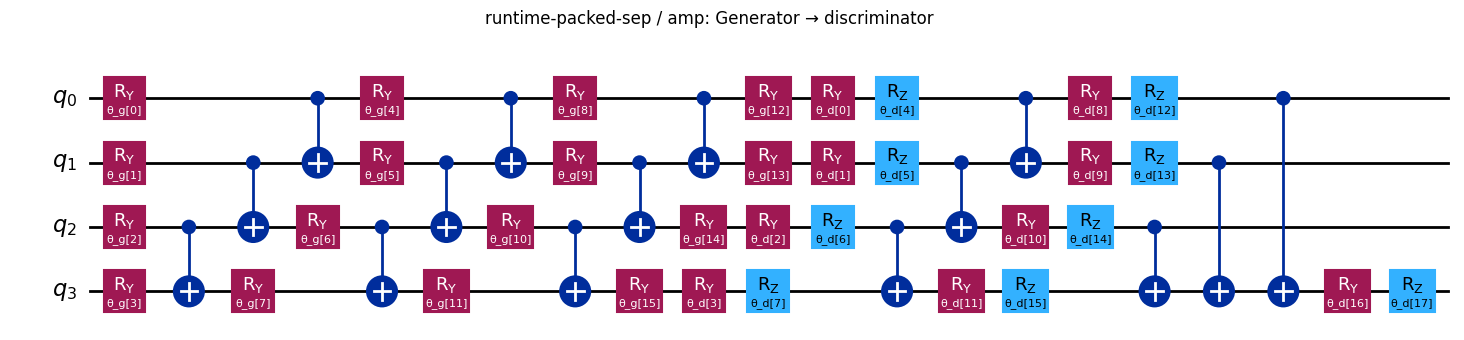

#### Generator training / fake discriminator circuit — 4 qubits

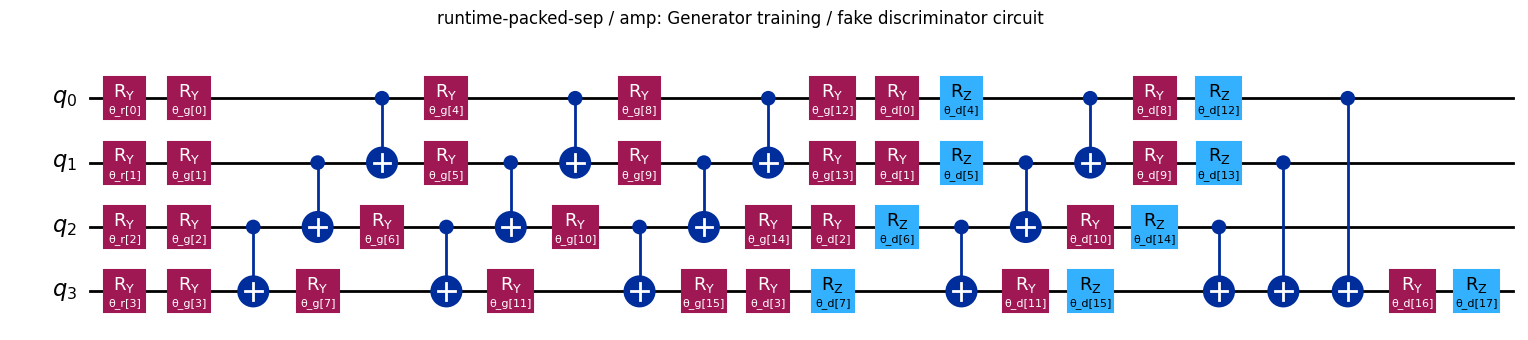

#### Real discriminator circuit — 4 qubits

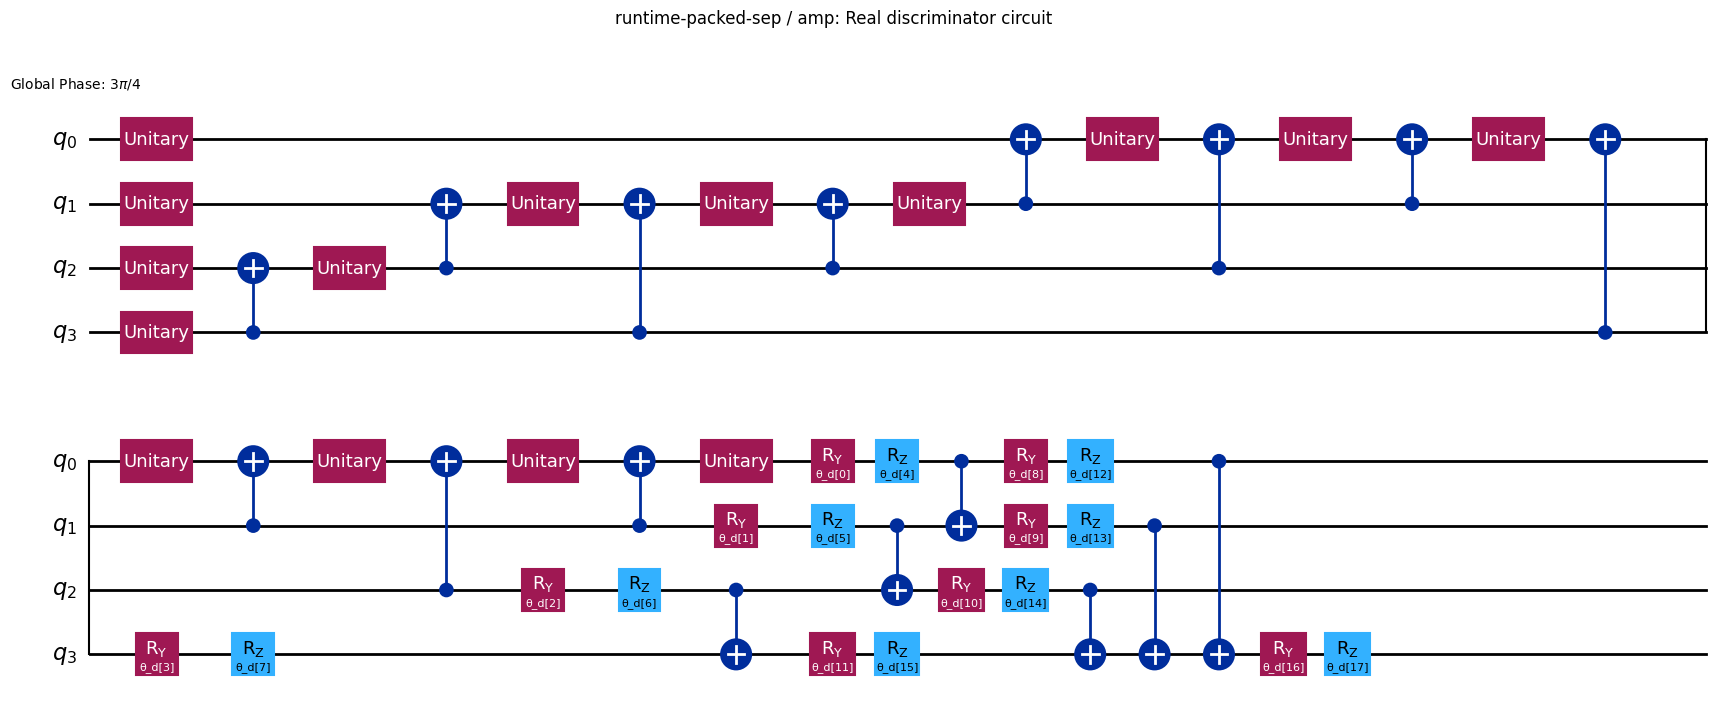

#### Generator training / fake discriminator packed job — 16 qubits

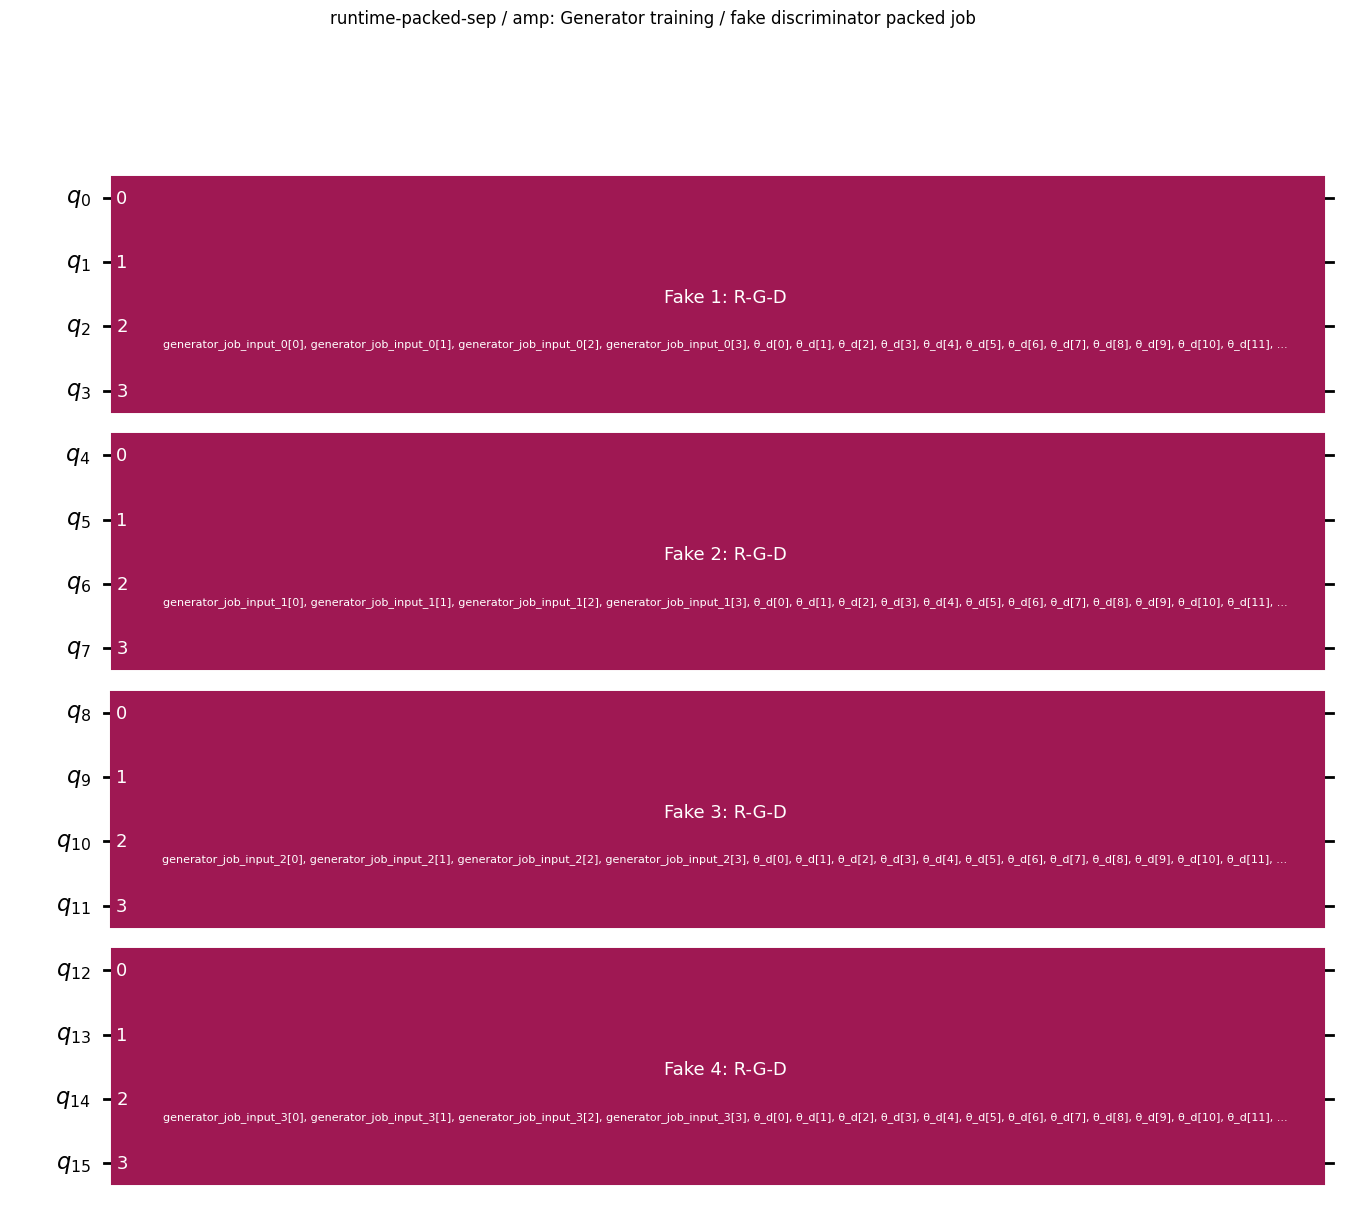

#### Real discriminator packed job — 16 qubits

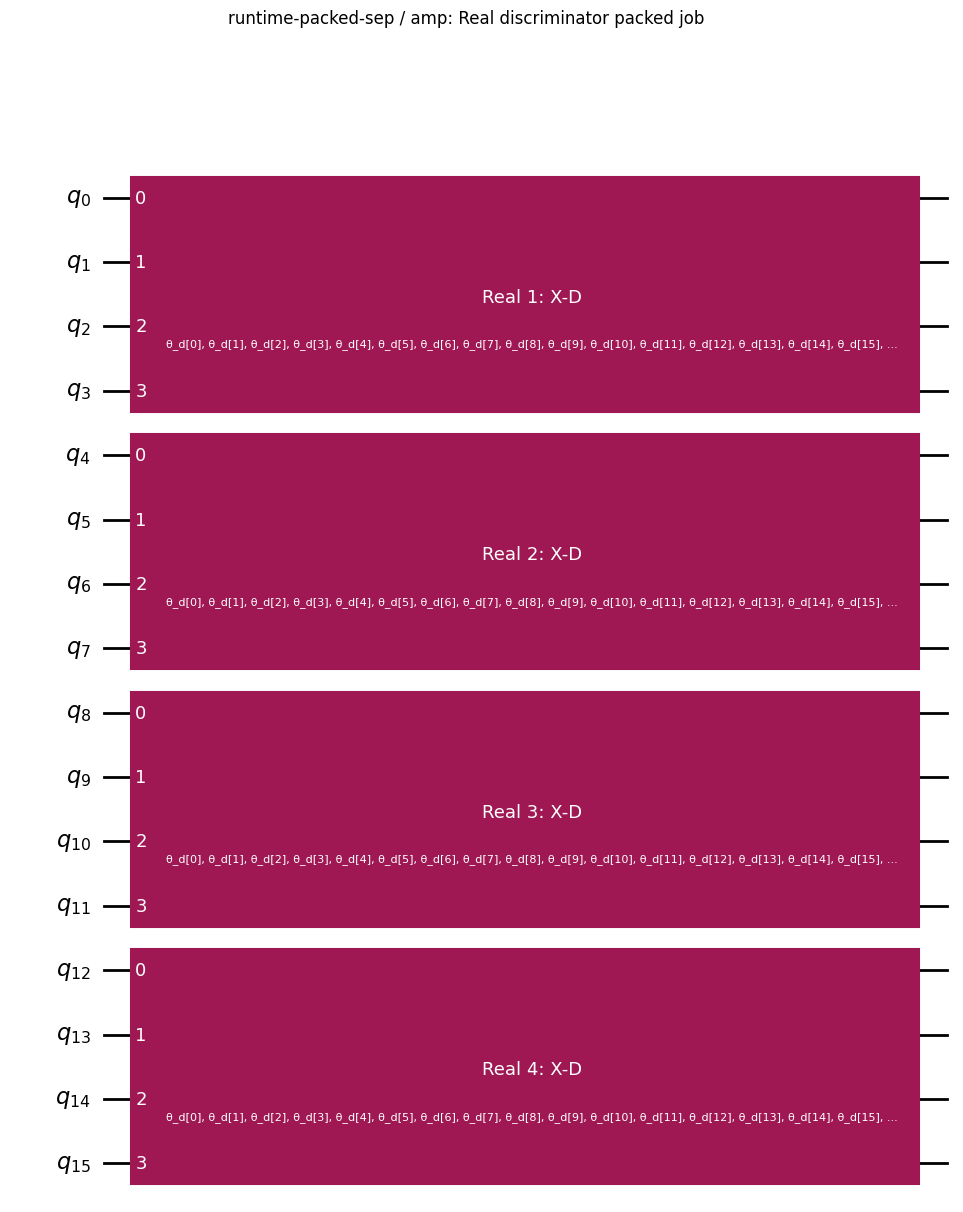

In [8]:
_ = atlas.show_case("amp", "runtime-packed-sep", save_figures=CREATE_PNG)

## runtime-packed-join

### base

The joined discriminator places one real and one fake branch on separate qubits.

**runtime-packed-join / base** · encoding: `direct_circuit` · real circuits: 1 · randomness: 1.0

#### Generator — 4 qubits

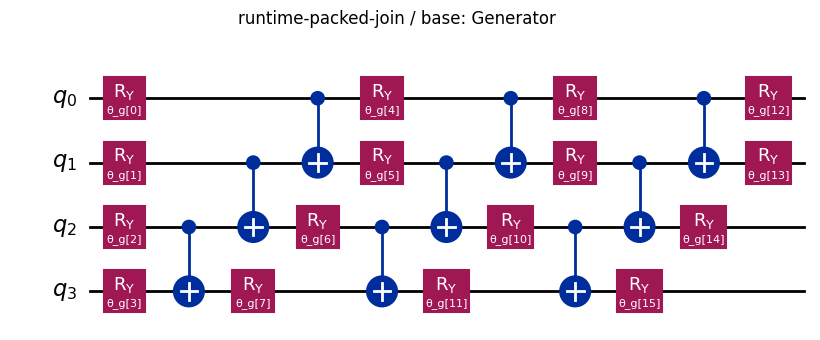

#### Discriminator — 4 qubits

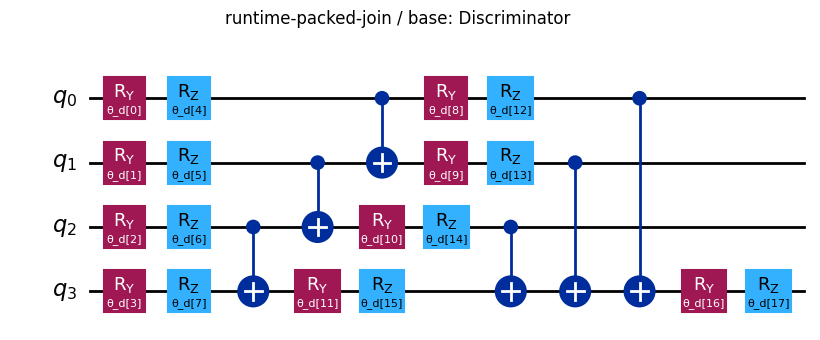

#### Real input (sample 0) — 4 qubits

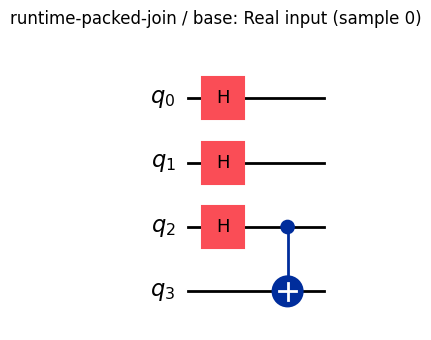

#### Random input — 4 qubits

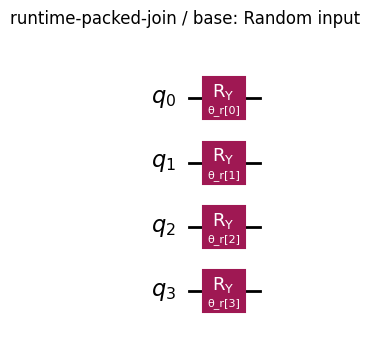

#### Random → generator — 4 qubits

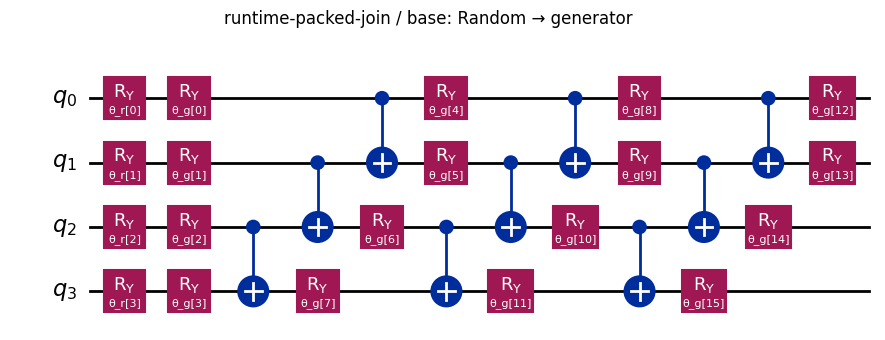

#### Generator → discriminator — 4 qubits

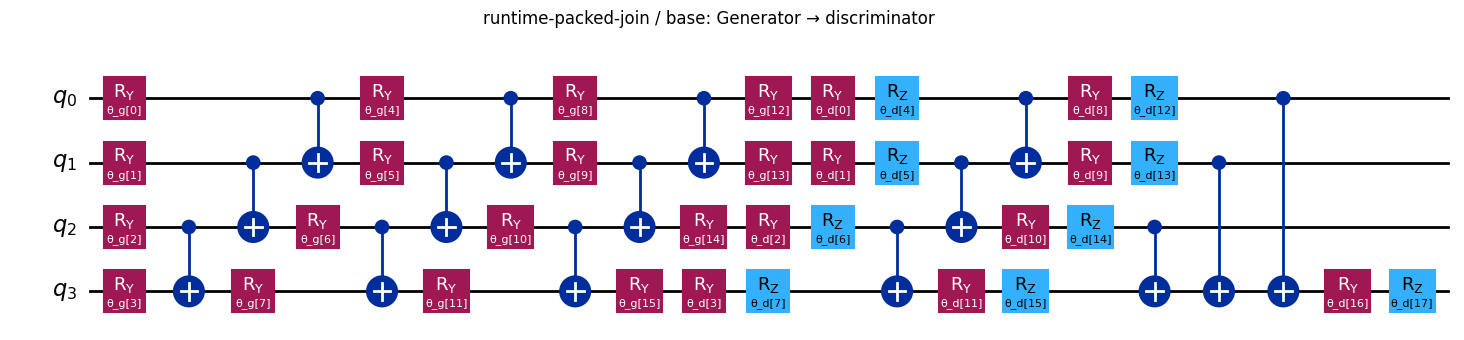

#### Generator training / fake discriminator circuit — 4 qubits

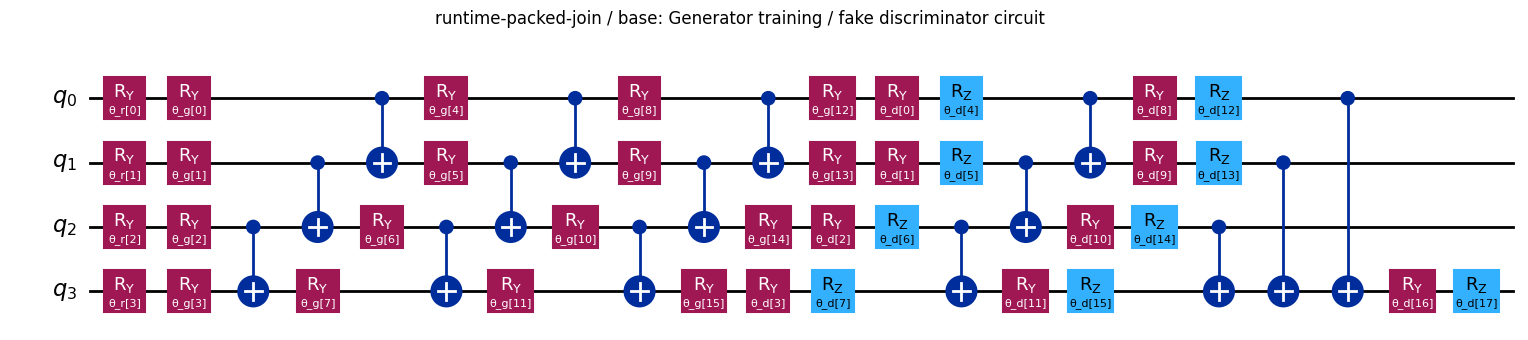

#### Real discriminator circuit — 4 qubits

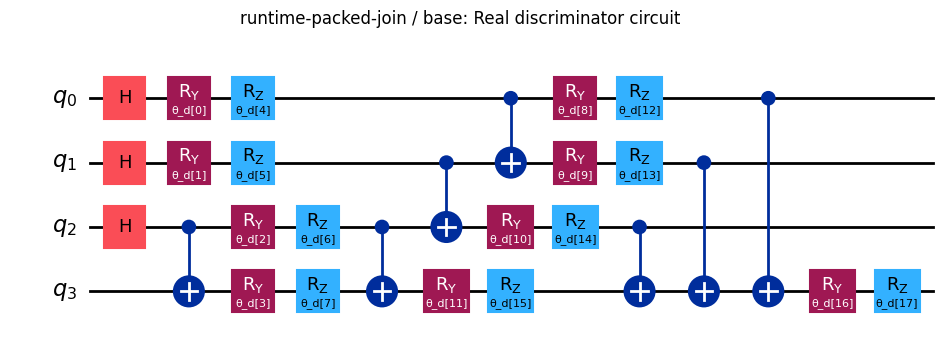

#### Joined discriminator circuit: one real and one fake branch — 8 qubits

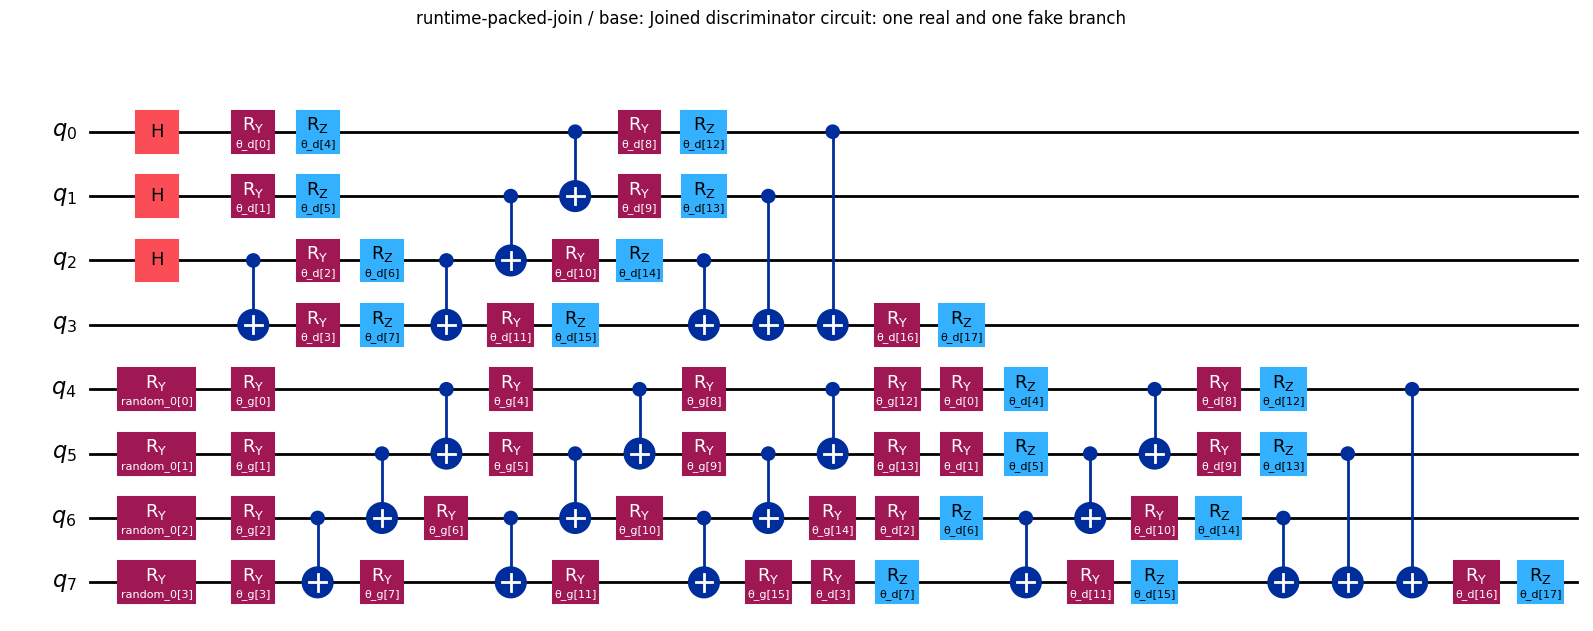

#### Generator training packed job — 4 qubits

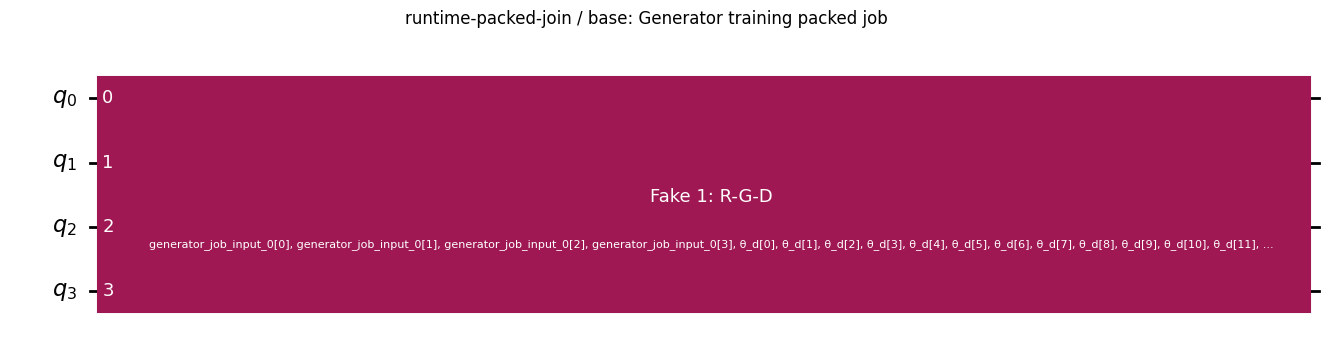

#### Joined discriminator packed job — 8 qubits

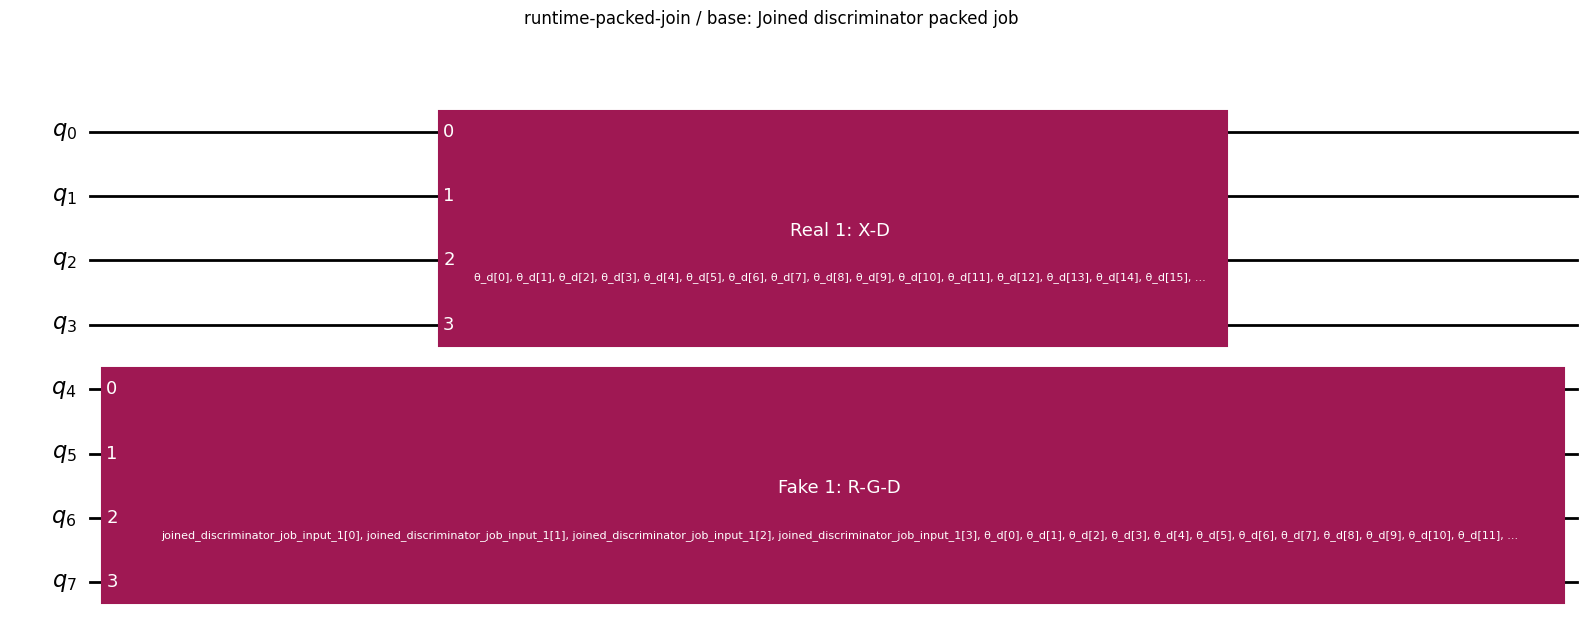

In [9]:
_ = atlas.show_case("base", "runtime-packed-join", save_figures=CREATE_PNG)

### ang

The joined discriminator splits the two-sample batch into one real and one fake branch.

**runtime-packed-join / ang** · encoding: `angle` · real circuits: 1 · randomness: 1.0

#### Generator — 4 qubits

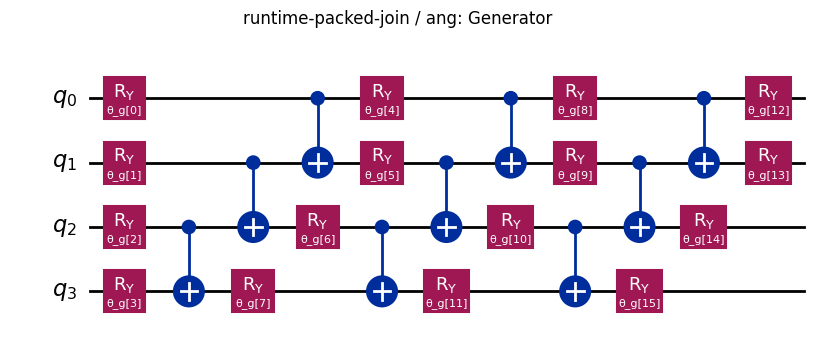

#### Discriminator — 4 qubits

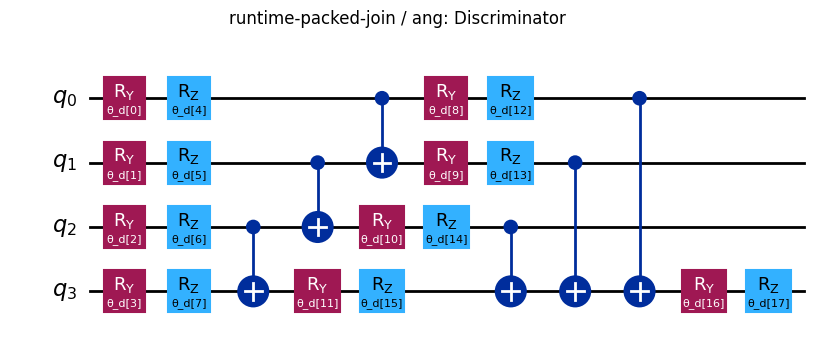

#### Real input (sample 0) — 4 qubits

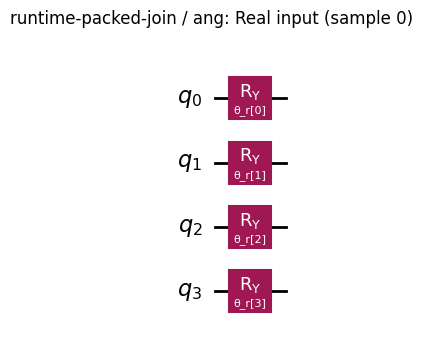

#### Random input — 4 qubits

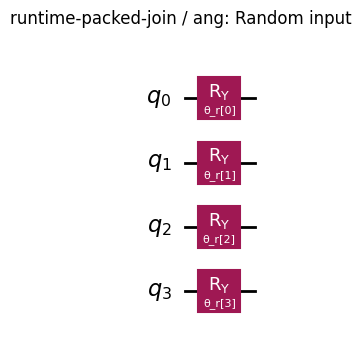

#### Random → generator — 4 qubits

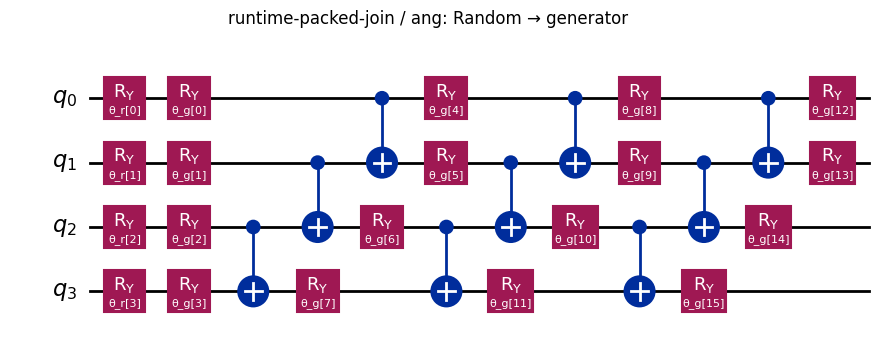

#### Generator → discriminator — 4 qubits

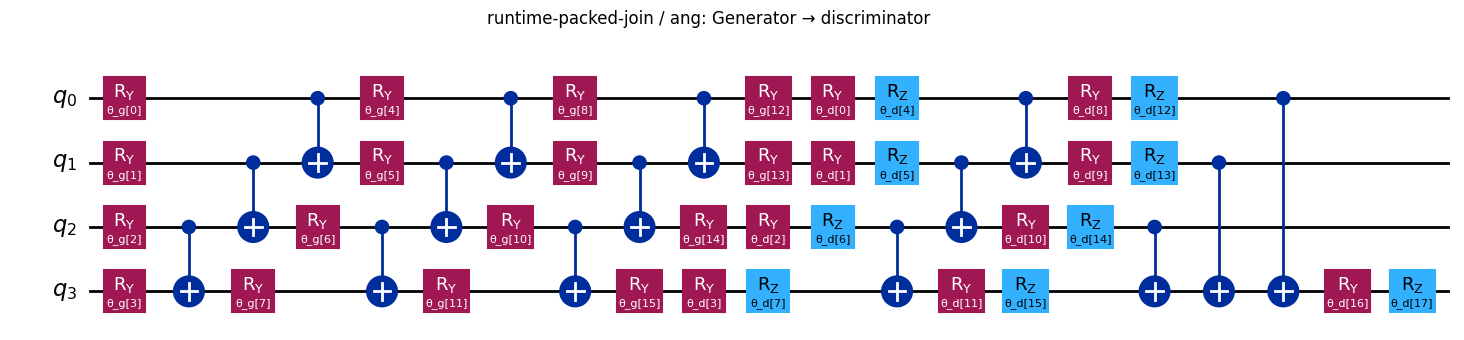

#### Generator training / fake discriminator circuit — 4 qubits

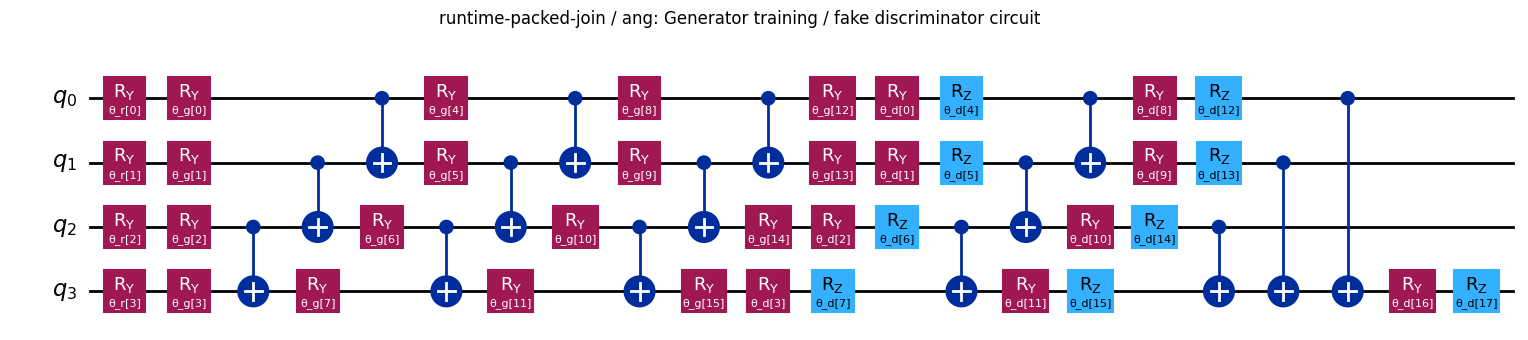

#### Real discriminator circuit — 4 qubits

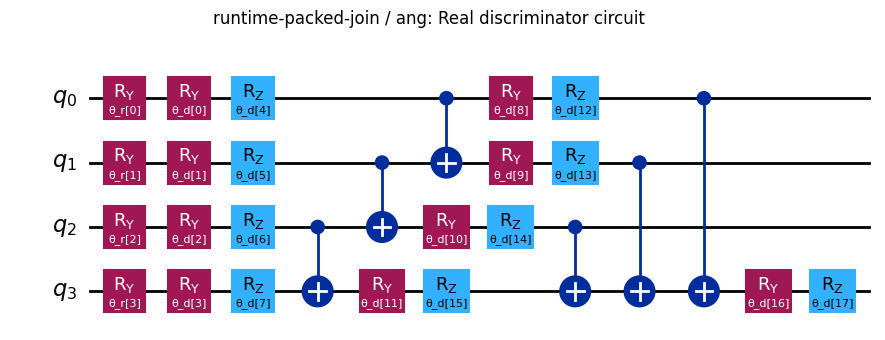

#### Joined discriminator circuit: one real and one fake branch — 8 qubits

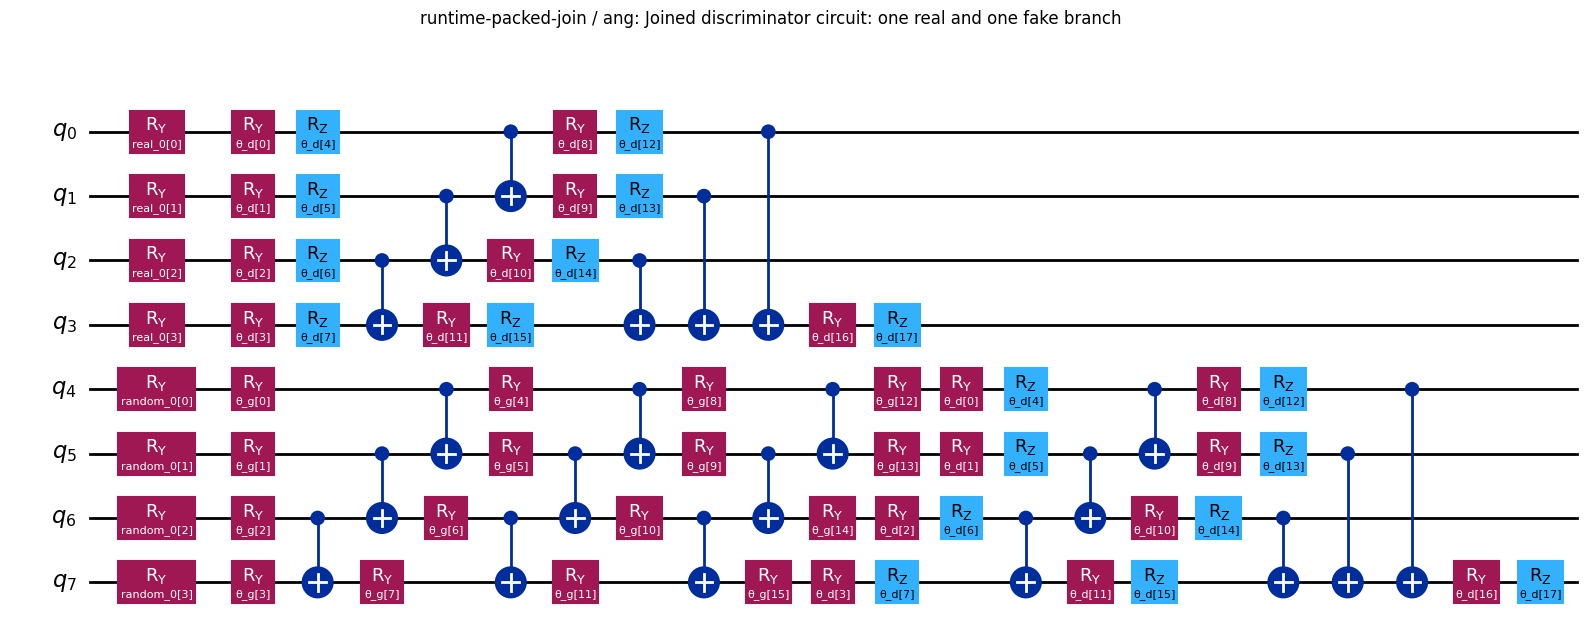

#### Generator training packed job — 16 qubits

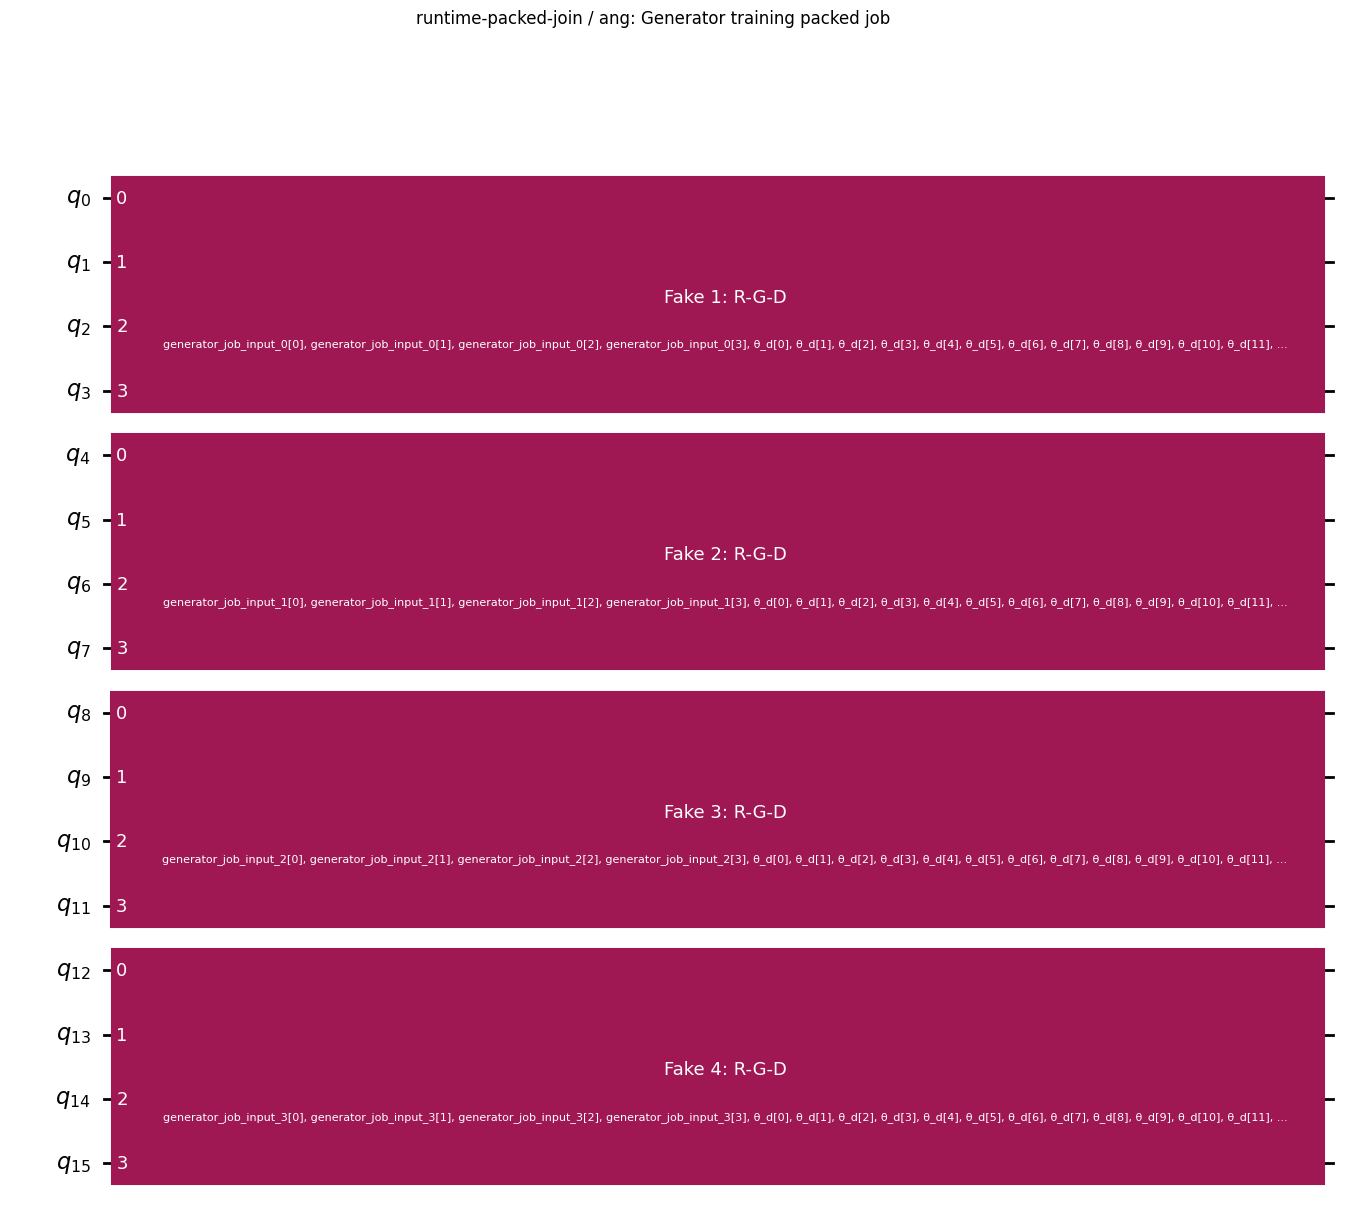

#### Joined discriminator packed job — 16 qubits

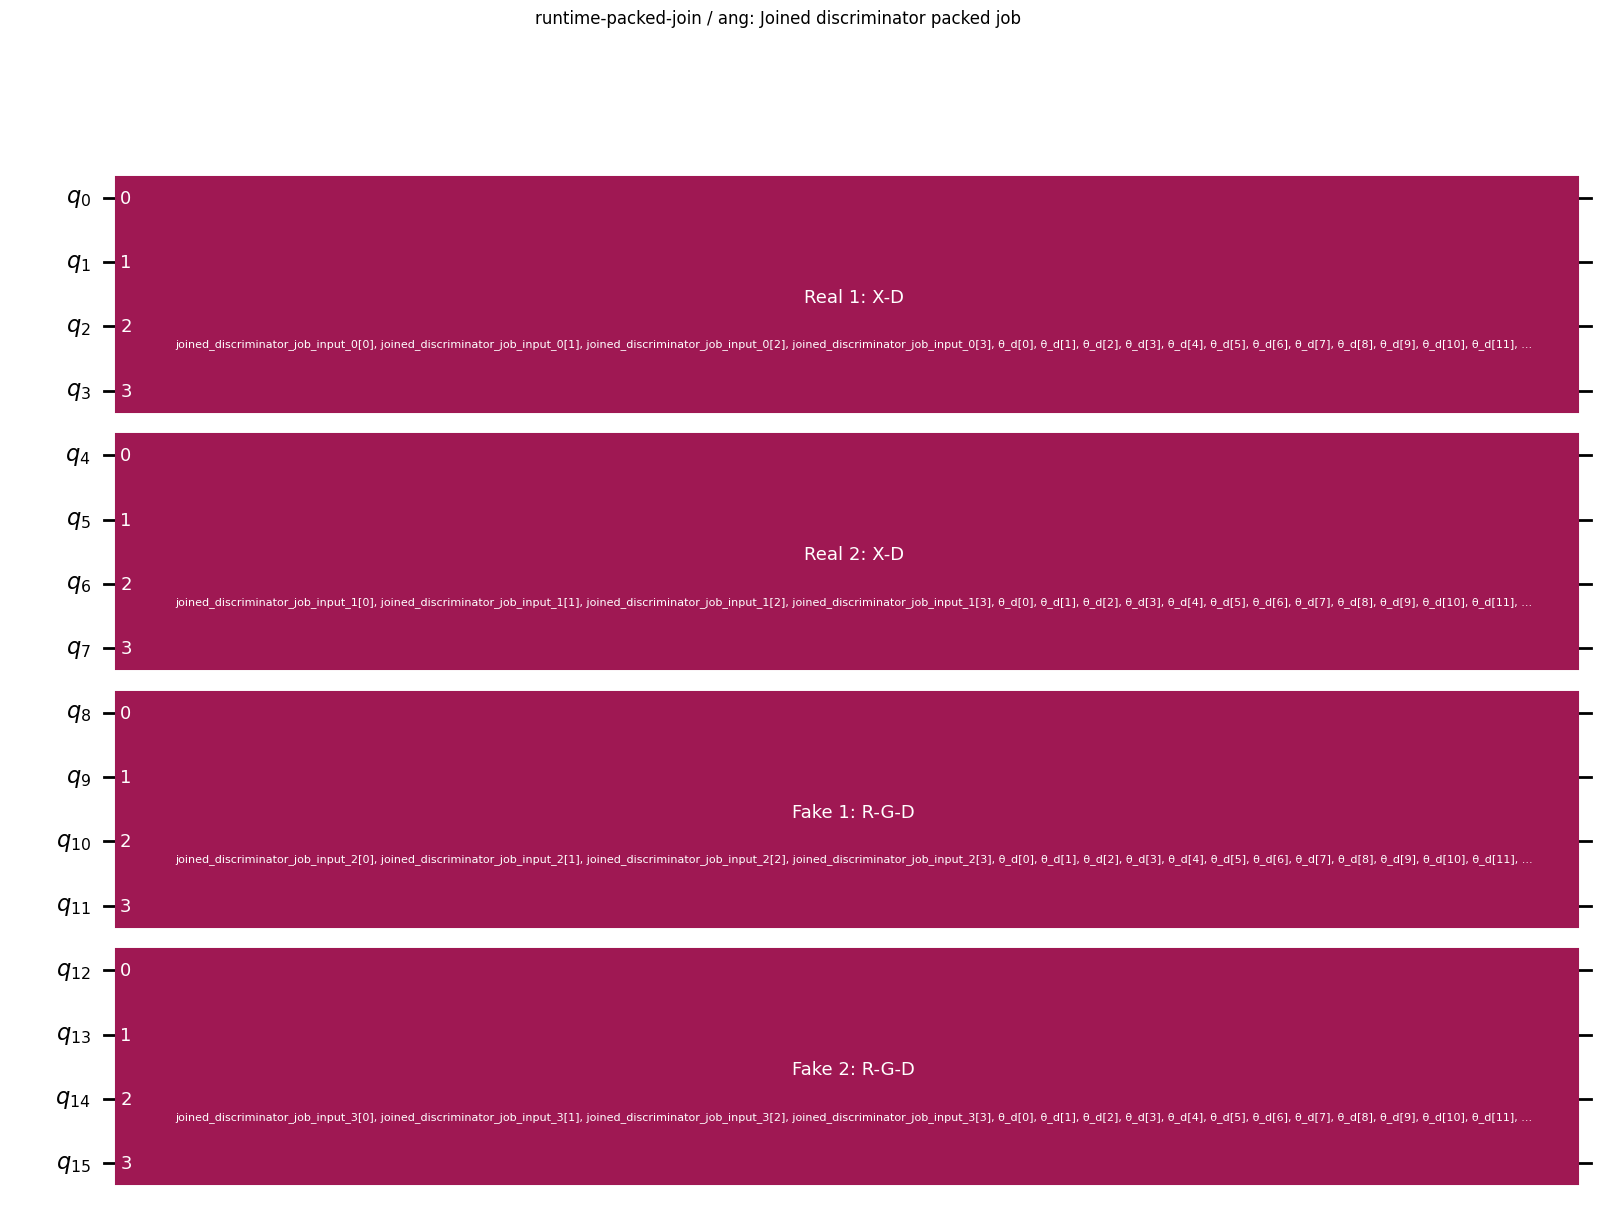

In [10]:
_ = atlas.show_case("ang", "runtime-packed-join", save_figures=CREATE_PNG)